# Experiments with hierarchical structure of text content
Prototyping an approach that combines both rule‐based and machine learning techniques to cluster document elements (pages, tables, paragraphs, sections, etc.) into semantic chunks based on key concepts and relationships:

---

### 1. Use Document Structure as a Starting Point

- **Sections as Natural Boundaries**:  
  Since the OCR output already includes a "sections" key with an ordered list of element pointers (e.g., “/paragraphs/0”, “/tables/2”), treat each section as a high-level unit.  
  - Extract all the content pointers from each section and gather the corresponding paragraphs, tables, figures, etc.

- **Key-Value Pairs for Data Relationships**:  
  Leverage the keyValuePairs to determine which pieces of text are functionally related (for example, a field label with its value). These can be merged with nearby text blocks in the same section.

---

### 2. Extract and Prepare Content for Semantic Analysis

- **Content Extraction**:  
  For each section, resolve the element pointers (e.g., "/paragraphs/1") to get the actual text, geometric positions, and any style metadata.

- **Preprocessing**:  
  - Concatenate related text segments from the same section if they appear to form a continuous thought.  
  - Optionally, include geometric cues (e.g., position or style features) if the document’s layout is significant.

- **Generate Representations**:  
  Compute text embeddings for each element using a model like Sentence-BERT or a multi-modal transformer (e.g., LayoutLMv3) that can combine textual and layout features. These embeddings will capture the semantic content.

---

### 3. Cluster Content Within and Across Sections

- **Within-Section Clustering**:  
  Within each section, you might further cluster content if the section itself contains multiple key concepts. For example, a "Results" section might have sub-clusters for numerical findings vs. descriptive paragraphs.
  - Use clustering algorithms (e.g., k-means or hierarchical clustering) on the embeddings of the section’s elements.
  - Adjust cluster granularity based on the number of elements and the expected diversity of key concepts.

- **Across-Section Relationships**:  
  If you need to find similarities between sections (for example, grouping together sections that are part of the introduction), you can compute embeddings for an entire section (by aggregating its element embeddings) and then cluster sections themselves.

- **Relationship-Based Refinement**:  
  Use key-value pairs and document metadata (like logical roles: headers, footers, etc.) as additional signals. For instance, if certain paragraphs are paired with key-value pairs (e.g., "Budget:" and "$10,000"), they likely belong in a single semantic group.

---

### 4. Merge and Label Semantic Chunks

- **Chunk Assembly**:  
  Once clusters are formed, merge the clustered items into semantic chunks. Each chunk should encapsulate:
  - A key concept (which might be determined by summarizing the text or by identifying a prominent heading).  
  - Supporting content (tables, figures, paragraphs, key-value pairs).

- **Annotation or Summarization**:  
  Optionally, run a summarization or classification step on each semantic chunk to assign it a label (e.g., “Introduction,” “Methodology,” “Results,” “Discussion”) or a custom key concept relevant to your domain.

---

### 5. Example Workflow Outline

1. **Load and Parse the OCR JSON**:  
   - Extract keys like `sections`, `paragraphs`, `tables`, etc.
   - For each section, follow the pointers in `sections/elements` to fetch the actual content.

2. **Preprocess Content**:  
   - Normalize text (e.g., remove extra whitespace).
   - Optionally, extract additional metadata (bounding boxes, styles).

3. **Compute Embeddings**:  
   - Use a text embedding model to encode the content of each element.

4. **Cluster the Elements**:  
   - Apply a clustering algorithm within each section (and optionally across sections) based on the embeddings.
   - Fine-tune the number of clusters or use a method that automatically determines clusters (e.g., DBSCAN).

5. **Assemble Semantic Chunks**:  
   - Group clusters into semantic chunks.
   - Optionally, apply a summarization model to label each chunk with a key concept.

6. **Post-Processing**:  
   - Merge adjacent or overlapping chunks using geometric cues.
   - Cross-reference key-value pairs to ensure related items are clustered together.

---

### 6. Considerations and Tools

- **Heuristic Rules**:  
  Simple rules (e.g., “if a table’s bounding box is within the vertical range of a heading’s section, attach it to that section”) can be very effective in documents with consistent layouts.

- **Machine Learning**:  
  Use pre-trained models for embeddings and clustering. Experiment with both sentence transformers and layout-aware models to see which best capture the semantic relationships.

- **Visualization and Manual Review**:  
  Visualize clusters (e.g., with t-SNE or UMAP) and conduct manual reviews to validate the semantic coherence of chunks.

---

### Final Thoughts

By combining the logical structure provided by headings and sections with geometric and key-value relationship cues, you can form semantic chunks that encapsulate key concepts along with their supporting data. This hybrid approach—using rule-based grouping for known structural elements and machine learning to capture semantic similarity—offers both interpretability and adaptability to different document types.

## OCR JSON Structure Documentation

This document describes the structure of the OCR JSON output (from Azure or a similar OCR service). The JSON contains a mix of extracted content (words, lines, paragraphs) along with their geometric and logical information, key-value pairs, tables, styles, language detection, sections, and figures.

---

### Top-Level Keys

- **apiVersion**  
  - *Type:* String  
  - *Description:* The API version used for the OCR output (e.g., `"2024-07-31-preview"`).

- **modelId**  
  - *Type:* String  
  - *Description:* Identifier of the OCR model used (e.g., `"prebuilt-layout"`).

- **stringIndexType**  
  - *Type:* String  
  - *Description:* Indicates how string indices are measured (e.g., `"utf16CodeUnit"`).

- **content**  
  - *Type:* String  
  - *Description:* The full raw text content extracted from the document. This is typically the concatenation of all recognized text.

- **contentFormat**  
  - *Type:* String  
  - *Description:* The format of the extracted content (e.g., `"text"`).

---

### Document Components

#### Pages

- **pages**  
  - *Type:* Array of Page Objects  
  - *Description:* Contains information for each page of the document.

Each **page** object includes:
  - **pageNumber**  
    - *Type:* Integer  
    - *Description:* The page number.
  - **angle**  
    - *Type:* Number (or `null`)  
    - *Description:* The rotation angle of the page.
  - **width**, **height**  
    - *Type:* Number  
    - *Description:* Dimensions of the page in the specified unit.
  - **unit**  
    - *Type:* String  
    - *Description:* The unit of measurement (e.g., `"pixel"`).
  - **words**  
    - *Type:* Array of Word Objects  
    - *Description:* Each word object contains:
      - **content:** The word text.
      - **polygon:** A flat array of numbers representing the polygon coordinates (e.g., `[x1, y1, x2, y2, ..., xN, yN]`).
      - **confidence:** Confidence score for the word.
      - **span:** An object with `offset` and `length` that indicate the position of this word in the overall text.
  - **lines**  
    - *Type:* Array of Line Objects  
    - *Description:* Each line object has:
      - **content:** The full text of the line.
      - **polygon:** The polygon coordinates (flat array) that enclose the line.
      - **spans:** List of span objects (each with `offset` and `length`).
  - **selectionMarks**  
    - *Type:* Array  
    - *Description:* Contains objects for selection marks (e.g., checkboxes), each with:
      - **state:** (e.g., `"selected"` or `"unselected"`).
      - **polygon:** The coordinates.
      - **confidence:** Confidence score.
      - **span:** The text span information.

---

#### Tables

- **tables**  
  - *Type:* Array of Table Objects  
  - *Description:* Represents tables extracted from the document.

Each **table** object includes:
  - **rowCount** and **columnCount**  
    - *Type:* Integer  
    - *Description:* The number of rows and columns.
  - **cells**  
    - *Type:* Array of Cell Objects  
    - *Description:* Each cell object may contain:
      - **kind:** The type of cell (e.g., `"columnHeader"`, `"body"`).
      - **rowIndex**, **columnIndex:** Position within the table.
      - **content:** The cell text.
      - **boundingRegions:** List of regions (each with a pageNumber and a flat polygon array).
      - **spans:** Span objects for text offsets.
      - **elements:** Pointers (e.g., `"/paragraphs/6"`) to the corresponding paragraph(s).
  - **boundingRegions**  
    - *Type:* Array  
    - *Description:* The overall region(s) where the table is located.
  - **spans**  
    - *Type:* Array  
    - *Description:* Span objects corresponding to the table text.

---

#### Paragraphs

- **paragraphs**  
  - *Type:* Array of Paragraph Objects  
  - *Description:* Contains the main text blocks extracted from the document.

Each **paragraph** object includes:
  - **spans**  
    - *Type:* Array of Span Objects  
    - *Description:* Each span contains:
      - **offset:** The starting position in the overall text.
      - **length:** The length of the text in this span.
  - **boundingRegions**  
    - *Type:* Array of Bounding Region Objects  
    - *Description:* Each region has:
      - **pageNumber:** The page number.
      - **polygon:** A flat array of numbers representing the bounding box of the paragraph.
  - **role** (Optional)  
    - *Type:* String  
    - *Description:* Logical role of the paragraph (e.g., `"title"`, `"pageFooter"`).
  - **content**  
    - *Type:* String  
    - *Description:* The text content of the paragraph.

---

#### Key-Value Pairs

- **keyValuePairs**  
  - *Type:* Array of Key-Value Pair Objects  
  - *Description:* Represents pairs of keys and values (often found in forms).

Each key-value pair object includes:
  - **key**  
    - *Type:* Object  
    - *Description:* Contains:
      - **content:** The key text.
      - **boundingRegions:** List of regions for the key.
      - **spans:** Span objects for text offsets.
  - **value**  
    - *Type:* Object  
    - *Description:* Contains:
      - **content:** The value text.
      - **boundingRegions:** List of regions for the value.
      - **spans:** Span objects.
  - **confidence**  
    - *Type:* Number  
    - *Description:* Confidence score for the key-value extraction.

---

#### Styles

- **styles**  
  - *Type:* Array of Style Objects  
  - *Description:* Contains style-related information such as font properties and handwriting detection.
  
Each **style** object includes:
  - **confidence:** Confidence score for the style detection.
  - **spans:** List of span objects indicating where this style applies.
  - **isHandwritten:** Boolean indicating if the text is handwritten.

---

#### Languages

- **languages**  
  - *Type:* Array of Language Objects  
  - *Description:* Contains language detection results for different spans of text.
  
Each **language** object includes:
  - **spans:** List of spans (with `offset` and `length`) where the language is detected.
  - **locale:** The language locale (e.g., `"en"`, `"pl"`).
  - **confidence:** Confidence score for the language detection.

---

#### Sections

- **sections**  
  - *Type:* Array of Section Objects  
  - *Description:* Logical sections of the document. Each section groups related elements.

Each **section** object includes:
  - **spans:** Array of span objects indicating which portions of the overall text belong to this section.
  - **elements:** Array of pointers (strings like `"/paragraphs/0"` or `"/tables/2"`) referencing the elements that belong to the section.

---

#### Figures

- **figures**  
  - *Type:* Array of Figure Objects  
  - *Description:* Represents images or figures extracted from the document.

Each **figure** object includes:
  - **id:** Identifier for the figure.
  - **boundingRegions:** Array of regions (each with a pageNumber and flat polygon array).
  - **spans:** Array of span objects.
  - **elements:** Array of pointers to associated paragraphs (if applicable).

---

### Example JSON Skeleton

Below is an example JSON snippet that shows the structure with inline comments (in Markdown, comments are shown as plain text):

```json
{
  "apiVersion": "2024-07-31-preview",
  "modelId": "prebuilt-layout",
  "stringIndexType": "utf16CodeUnit",
  "content": "Full raw text content...",
  "contentFormat": "text",
  "pages": [
    {
      "pageNumber": 1,
      "angle": 0.14,
      "width": 762,
      "height": 1000,
      "unit": "pixel",
      "words": [
        {
          "content": "MARKETING",
          "polygon": [238, 41, 302, 40, 302, 56, 238, 56],
          "confidence": 0.989,
          "span": {"offset": 0, "length": 9}
        }
        // ... more words ...
      ],
      "lines": [
        {
          "content": "MARKETING RESEARCH AUTHORIZATIU ..",
          "polygon": [238, 40, 466, 40, 466, 56, 238, 56],
          "spans": [{"offset": 0, "length": 34}]
        }
        // ... more lines ...
      ]
    }
    // ... more pages ...
  ],
  "tables": [
    {
      "rowCount": 3,
      "columnCount": 5,
      "cells": [
        {
          "kind": "columnHeader",
          "rowIndex": 0,
          "columnIndex": 0,
          "content": "",
          "boundingRegions": [
            {"pageNumber": 1, "polygon": [278, 109, 291, 109, 291, 138, 278, 138]}
          ],
          "spans": []
        }
        // ... more cells ...
      ],
      "boundingRegions": [
        {"pageNumber": 1, "polygon": [311, 121, 623, 121, 623, 167, 310, 167]}
      ],
      "spans": [{"offset": 170, "length": 44}]
    }
    // ... more tables ...
  ],
  "paragraphs": [
    {
      "spans": [{"offset": 0, "length": 66}],
      "boundingRegions": [
        {"pageNumber": 1, "polygon": [238, 40, 466, 40, 466, 70, 238, 71]}
      ],
      "role": "title",
      "content": "MARKETING RESEARCH AUTHORIZATIU .. (Recommended Proposal Attached)"
    }
    // ... more paragraphs ...
  ],
  "keyValuePairs": [
    {
      "key": {
        "content": "Date:",
        "boundingRegions": [
          {"pageNumber": 1, "polygon": [80, 69, 114, 69, 114, 84, 80, 84]}
        ],
        "spans": [{"offset": 67, "length": 5}]
      },
      "value": {
        "content": "4/16/90",
        "boundingRegions": [
          {"pageNumber": 1, "polygon": [121, 69, 181, 69, 181, 83, 121, 83]}
        ],
        "spans": [{"offset": 73, "length": 7}]
      },
      "confidence": 0.999
    }
    // ... more keyValuePairs ...
  ],
  "styles": [
    {
      "confidence": 1,
      "spans": [{"offset": 1034, "length": 11}],
      "isHandwritten": true
    }
    // ... more styles ...
  ],
  "languages": [
    {
      "spans": [{"offset": 0, "length": 34}],
      "locale": "en",
      "confidence": 0.4
    }
    // ... more languages ...
  ],
  "sections": [
    {
      "spans": [
        {"offset": 0, "length": 214},
        {"offset": 1349, "length": 12},
        {"offset": 215, "length": 27},
        {"offset": 1362, "length": 12},
        {"offset": 243, "length": 1062}
      ],
      "elements": [
        "/paragraphs/0",
        "/paragraphs/1",
        "/paragraphs/2"
        // ... additional element pointers ...
      ]
    }
  ],
  "figures": [
    {
      "id": "1.1",
      "boundingRegions": [
        {"pageNumber": 1, "polygon": [229, 25, 474, 25, 474, 71, 229, 71]}
      ],
      "spans": [{"offset": 0, "length": 66}],
      "elements": ["/paragraphs/0"]
    }
  ]
}
```

# Coding starts here.

---

## Section 1: Converting OCR JSON to respect atomic key-values and tables

---

## Atomic Key-Pairs by generating paragraph representation 

### Overview
Below is an updated version of the merging code. In this version, instead of creating a separate key (e.g. `"mergedParagraphs"`), the new merged paragraphs are appended directly into the `"paragraphs"` list. The original paragraphs that contributed to a merge are marked with `"invalid": true` and a `"mergedInto"` pointer, so you can later filter or review them if needed.

### TODO
Fix paragraph numbering so merged paragraphs ids are numbered starting with the current maximum + 1. See Atomic Table code for example.

Done.

---

### How This Code Works

- **Helper Functions:**  
  - `polygon_to_bbox` converts a flat polygon array into a bounding box.  
  - `union_bbox` computes the union of multiple bounding boxes.  
  - `compute_iou` computes the intersection-over-union between two boxes.  
  - `get_paragraph_bbox` computes the overall bounding box of a paragraph by unioning its regions.

- **create_merged_paragraph:**  
  Constructs a new paragraph element with merged content and a union bounding box. It also stores `"contributingParagraphs"` that lists the IDs (or indices) of the original key and value paragraphs.

- **merge_key_value_pairs_create_new_paragraphs:**  
  For each key–value pair in the OCR JSON, it identifies the best matching paragraphs for the key and value (using IoU) and then creates a new merged paragraph element. Instead of replacing the key paragraph or deleting the value paragraph, the merged paragraph is appended to the `"paragraphs"` list. The original paragraphs are marked with `"invalid": True` and have a `"mergedInto"` field pointing to the new merged paragraph’s ID.

- **main:**  
  Loads the OCR JSON, processes it with the merging function, and writes the updated JSON back to disk.

This approach keeps the original paragraph structure intact while appending new merged paragraphs. This makes it easier to trace the original data and extend merging logic (for example, merging key–value pairs inside tables) in the future.

### Notes
This code required updates to the clustering code namely,
1. Recognize the `invalid` flag and ignore paragraph if required
2. Save the actual paragraph `ids` in a dictionary version of `cluster_labels` rather than relying on the order the paragraphs are in the JSON.

In [1]:
import os
import json
import numpy as np

def get_max_paragraph_id(ocr_json):
    """
    Return the maximum paragraph id among the paragraphs.
    """
    ids = []
    for para in ocr_json.get("paragraphs", []):
        try:
            ids.append(int(para.get("id")))
        except Exception:
            continue
    print("ids", ids)
    return max(ids) if ids else 1000

def polygon_to_bbox(polygon):
    """
    Convert a flat polygon array into a bounding box [x_min, y_min, x_max, y_max].
    Assumes polygon is a flat list of numbers: [x1, y1, x2, y2, ...].
    """
    pts = np.array(polygon).reshape(-1, 2)
    x_min = float(pts[:, 0].min())
    y_min = float(pts[:, 1].min())
    x_max = float(pts[:, 0].max())
    y_max = float(pts[:, 1].max())
    return [x_min, y_min, x_max, y_max]

def bbox_to_polygon(bbox):
    """
    Convert a bounding box [x_min, y_min, x_max, y_max] into a flattened polygon array 
    with four points: top-left, top-right, bottom-right, bottom-left.
    """
    x_min, y_min, x_max, y_max = bbox
    return [x_min, y_min, x_max, y_min, x_max, y_max, x_min, y_max]

def union_bbox(bbox_list):
    """
    Given a list of bounding boxes [x_min, y_min, x_max, y_max],
    return the union bounding box that encloses them all.
    """
    if not bbox_list:
        return None
    xmins = [b[0] for b in bbox_list]
    ymins = [b[1] for b in bbox_list]
    xmaxs = [b[2] for b in bbox_list]
    ymaxs = [b[3] for b in bbox_list]
    return [min(xmins), min(ymins), max(xmaxs), max(ymaxs)]

def compute_iou(bbox1, bbox2):
    """Compute Intersection over Union (IoU) for two bounding boxes."""
    xA = max(bbox1[0], bbox2[0])
    yA = max(bbox1[1], bbox2[1])
    xB = min(bbox1[2], bbox2[2])
    yB = min(bbox1[3], bbox2[3])
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH
    area1 = (bbox1[2]-bbox1[0]) * (bbox1[3]-bbox1[1])
    area2 = (bbox2[2]-bbox2[0]) * (bbox2[3]-bbox2[1])
    unionArea = area1 + area2 - interArea
    return interArea / unionArea if unionArea else 0

def get_paragraph_bbox(para):
    """
    Compute the overall bounding box for a paragraph by unioning its boundingRegions.
    """
    bboxes = []
    for region in para.get("boundingRegions", []):
        poly = region.get("polygon", [])
        if poly:
            bboxes.append(polygon_to_bbox(poly))
    if bboxes:
        return union_bbox(bboxes)
    return None

def create_merged_paragraph(key_para, value_para):
    """
    Create a new merged paragraph element.
    The new paragraph element will:
      - Concatenate key and value content.
      - Compute a merged bounding box (union of key and value bboxes),
        then convert that bbox into a full polygon with 8 entries.
      - Create a new span.
      - Record contributing paragraph IDs.
    """
    key_text = key_para.get("content", "").strip()
    value_text = value_para.get("content", "").strip()
    merged_text = key_text + " " + value_text if value_text not in key_text else key_text

    key_bbox = get_paragraph_bbox(key_para)
    value_bbox = get_paragraph_bbox(value_para)
    merged_bbox = union_bbox([key_bbox, value_bbox])
    merged_poly = bbox_to_polygon(merged_bbox) if merged_bbox else []

    # Copy pageNumber from key paragraph's first bounding region if available.
    page_number = None
    if key_para.get("boundingRegions"):
        page_number = key_para["boundingRegions"][0].get("pageNumber")

    merged_region = {
        "pageNumber": page_number,
        "polygon": merged_poly
    }
    
    new_span = {"offset": 0, "length": len(merged_text)}
    
    merged_para = {
        "content": merged_text,
        "boundingRegions": [merged_region],
        "spans": [new_span],
        "contributingParagraphs": [key_para.get("id", None), value_para.get("id", None)]
    }
    return merged_para

def merge_key_value_pairs_create_new_paragraphs(ocr_json, iou_threshold=0.1):
    """
    Process each keyValuePair in the OCR JSON:
      - Identify the best matching key paragraph and value paragraph.
      - Create a new merged paragraph element.
      - Append the new merged paragraph into the OCR JSON's "paragraphs" list.
      - Mark the original key and value paragraphs with "invalid": True and "mergedInto": <merged_id>.
    """
    paragraphs = ocr_json.get("paragraphs", [])
    
    # Ensure each paragraph has an "id"
    for idx, para in enumerate(paragraphs):
        if "id" not in para:
            para["id"] = idx

    new_merged_paragraphs = []
    merged_paragraphs_current_id = get_max_paragraph_id(ocr_json) + 1

    for kv in ocr_json.get("keyValuePairs", []):
        key_obj = kv.get("key", {})
        value_obj = kv.get("value", {})
        if not key_obj or not value_obj:
            continue

        key_bboxes = [polygon_to_bbox(r.get("polygon", []))
                      for r in key_obj.get("boundingRegions", [])
                      if r.get("polygon")]
        value_bboxes = [polygon_to_bbox(r.get("polygon", []))
                        for r in value_obj.get("boundingRegions", [])
                        if r.get("polygon")]
        if not key_bboxes or not value_bboxes:
            continue

        key_bbox_union = union_bbox(key_bboxes)
        value_bbox_union = union_bbox(value_bboxes)

        best_key_iou = 0
        best_key_idx = None
        best_value_iou = 0
        best_value_idx = None

        for idx, para in enumerate(paragraphs):
            para_bbox = get_paragraph_bbox(para)
            if para_bbox is None:
                continue
            iou_key = compute_iou(key_bbox_union, para_bbox)
            iou_value = compute_iou(value_bbox_union, para_bbox)
            if iou_key > best_key_iou:
                best_key_iou = iou_key
                best_key_idx = idx
            if iou_value > best_value_iou:
                best_value_iou = iou_value
                best_value_idx = idx

        if (best_key_idx is not None and best_value_idx is not None and 
            best_key_idx != best_value_idx and 
            best_key_iou >= iou_threshold and best_value_iou >= iou_threshold):
            
            key_para = paragraphs[best_key_idx]
            value_para = paragraphs[best_value_idx]

            merged_para = create_merged_paragraph(key_para, value_para)
            # Assign a new ID to the merged paragraph.
            merged_para["id"] = merged_paragraphs_current_id #f"merged_{key_para.get('id')}_{value_para.get('id')}"
            # add key value key information
            merged_para["key_value_pairs"] = [{"key":key_obj["content"], "value": value_obj["content"]}]

            merged_paragraphs_current_id += 1
            new_merged_paragraphs.append(merged_para)
            
            # Mark original paragraphs as merged.
            key_para["invalid"] = True
            key_para["mergedInto"] = merged_para["id"]

            value_para["invalid"] = True
            value_para["mergedInto"] = merged_para["id"]


    # Append new merged paragraphs to the existing paragraphs list.
    ocr_json["paragraphs"].extend(new_merged_paragraphs)
    return ocr_json

input_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout.json'   # Update with your OCR JSON file path
output_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged_new_kp.json'

with open(input_path, "r", encoding="utf-8") as f:
    ocr_data = json.load(f)

updated_ocr = merge_key_value_pairs_create_new_paragraphs(ocr_data, iou_threshold=0.1)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(updated_ocr, f, indent=2)

print(f"Updated OCR JSON written to {output_path}")


ids [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]
Updated OCR JSON written to ../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged_new_kp.json


## Atomic Tables by generating paragraph representation 

### Overview
Below is an updated version of the merge function that, for each table, uses the table’s own `"boundingRegions"` (as provided in the table JSON) for the new merged paragraph. This code converts the table’s content into CSV text, creates a new paragraph element whose `"boundingRegions"` is taken directly from the table, and then marks any paragraphs referenced by the table as invalid while appending the new merged paragraph into the existing `"paragraphs"` list.

### TODO
Need to look after previously merged key-value pairs

Update: Now invalidating merged to paragraphs. For this set the merged to occures twice in all cases, i.e. both parts of key pairs exist in the same tables.

---

### Explanation

1. **get_table_csv:**  
   Converts table cell contents into a CSV-formatted string based on row and column indices.

2. **find_paragraph_by_pointer:**  
   Finds a paragraph in the OCR JSON by parsing a pointer string like `"/paragraphs/6"`.

3. **get_max_paragraph_id:**  
   Determines the maximum existing paragraph ID so that new merged paragraphs can get a unique ID.

4. **merge_table_to_paragraph:**  
   - For each table, the CSV text is generated.
   - The table’s `"boundingRegions"` are used directly (without recomputing a union).
   - All paragraph IDs referenced by table cells are collected as contributing paragraphs.
   - A new merged paragraph is created with the CSV text, the table's bounding regions, a span covering the CSV text, and a `"contributingParagraphs"` key.
   - Each contributing paragraph is then marked with `"invalid": true` and a `"mergedInto"` pointer.
   - Finally, the new paragraph is appended to the existing `"paragraphs"` list.

This approach allows you to incorporate table data into the paragraph structure while preserving the original OCR data for review or further processing.

In [3]:
import os
import json

def get_table_csv(table):
    """
    Convert a table's cell contents into a CSV string.
    Uses the "rowIndex" and "columnIndex" to build a grid.
    """
    rows = table.get("rowCount", 0)
    cols = table.get("columnCount", 0)
    # Initialize grid with empty strings.
    grid = [["" for _ in range(cols)] for _ in range(rows)]
    
    for cell in table.get("cells", []):
        row = cell.get("rowIndex", 0)
        col = cell.get("columnIndex", 0)
        text = cell.get("content", "").strip()
        grid[row][col] = text

    # Create CSV lines by joining each row with commas.
    csv_lines = [",".join(row) for row in grid]
    return "\n".join(csv_lines)

def find_paragraph_by_pointer(ocr_json, pointer):
    """
    Given a pointer string (e.g., "/paragraphs/6"), return the corresponding paragraph object
    from ocr_json["paragraphs"]. Assumes pointer format is fixed.
    """
    try:
        _, _, id_str = pointer.partition("/paragraphs/")
        target_id = int(id_str)
    except Exception:
        return None

    for para in ocr_json.get("paragraphs", []):
        try:
            if int(para.get("id", -1)) == target_id:
                return para
        except Exception:
            continue
    return None

def get_max_paragraph_id(ocr_json):
    """
    Return the maximum paragraph id among the paragraphs.
    """
    ids = []
    for para in ocr_json.get("paragraphs", []):
        try:
            ids.append(int(para.get("id")))
        except Exception:
            continue
    return max(ids) if ids else 0

def merge_table_to_paragraph(ocr_json):
    """
    For each table in ocr_json["tables"]:
      - Convert the table cells to CSV text.
      - Use the table's own "boundingRegions" as the new paragraph's boundingRegions.
      - For each cell that references a paragraph via "elements", mark that paragraph as invalid and set "mergedInto".
      - Create a new paragraph element with:
          * "content": the CSV text,
          * "boundingRegions": the table's boundingRegions,
          * "spans": a new span covering the CSV text,
          * "contributingParagraphs": a list of paragraph ids referenced by the table.
      - Append the new paragraph to ocr_json["paragraphs"].
    """
    paragraphs = ocr_json.get("paragraphs", [])
    
    # Ensure each paragraph has an "id"
    for idx, para in enumerate(paragraphs):
        if "id" not in para:
            para["id"] = idx

    max_id = get_max_paragraph_id(ocr_json)
    new_paragraphs = []

    for table in ocr_json.get("tables", []):
        csv_text = get_table_csv(table)
        
        # Use the table's boundingRegions directly.
        table_regions = table.get("boundingRegions", [])
        if not table_regions:
            continue
        
        # Collect contributing paragraph ids from the table's cells.
        contributing_ids = set()
        for cell in table.get("cells", []):
            for pointer in cell.get("elements", []):
                para_obj = find_paragraph_by_pointer(ocr_json, pointer)
                if para_obj and "id" in para_obj:
                    contributing_ids.add(int(para_obj["id"]))
        
        # Create a new paragraph element for the merged table.
        new_id = max_id + 1
        max_id += 1
        new_para = {
            "id": new_id,
            "content": csv_text,
            "boundingRegions": table_regions,  # Directly use table's boundingRegions.
            "spans": [{"offset": 0, "length": len(csv_text)}],
            "contributingParagraphs": list(contributing_ids)
        }
        
        # Mark the contributing paragraphs as invalid and note their mergedInto.
        # and collect any key pairs
        key_pairs = []
        key_pairs_processed = []

        for pid in contributing_ids:
            for para in paragraphs:
                try:
                    if int(para.get("id")) == pid:
                        para["invalid"] = True

                        # if previously merged we need to invalidate the merged to paragraph
                        merged_to_p = int(para.get("mergedInto", -1))

                        if merged_to_p != -1:
                            # find the para with that id
                            result_p = next((para for para in ocr_data["paragraphs"] if int(para.get("id", -1)) == merged_to_p), None)
                            if result_p:
                                print("Found paragraph:", result_p)
                                # set it invalid
                                result_p["invalid"] = True

                                # add in any key pairs in the merged contributed paragraphs
                                key_pairs_p = result_p.get("key_value_pairs", None)
                                if key_pairs_p:
                                    if merged_to_p not in key_pairs_processed:
                                        key_pairs.append(key_pairs_p)
                                        key_pairs_processed.append(merged_to_p)

                            # else:
                            #     print("Paragraph not found.")
                        
                        # point each paragraph to our new addition
                        para["mergedInto"] = new_id

                        # add in any key pairs in the contributed paragraphs
                        key_pairs_p = para.get("key_value_pairs", None)
                        if key_pairs_p:
                            key_pairs.append(key_pairs_p)
    
                except Exception:
                    continue

        # add key pairs to table merge paragraph
        if key_pairs:
            new_para["key_value_pairs"] = key_pairs
        new_paragraphs.append(new_para)
        print(f"New paragraph {json.dumps(new_para)}")

    # Append new merged paragraphs into the existing paragraphs list.
    ocr_json["paragraphs"].extend(new_paragraphs)
    return ocr_json

input_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged_new_kp.json'  # Update with your input file path.
output_path = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged_new_kp-table.json'

with open(input_path, "r", encoding="utf-8") as f:
    updated_ocr = json.load(f)

# take JSON after fixing key-pairs
updated_table_ocr = merge_table_to_paragraph(updated_ocr)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(updated_table_ocr, f, indent=2)

print(f"Updated OCR JSON with merged table paragraphs written to {output_path}")


Found paragraph: {'content': 'Budgeted Amount 23.3', 'boundingRegions': [{'pageNumber': 1, 'polygon': [373.0, 150.0, 610.0, 150.0, 610.0, 165.0, 373.0, 165.0]}], 'spans': [{'offset': 0, 'length': 20}], 'contributingParagraphs': [12, 13], 'id': 88, 'key_value_pairs': [{'key': 'Original Budgeted Amount', 'value': '23.3'}]}
Found paragraph: {'content': 'Budgeted Amount 23.3', 'boundingRegions': [{'pageNumber': 1, 'polygon': [373.0, 150.0, 610.0, 150.0, 610.0, 165.0, 373.0, 165.0]}], 'spans': [{'offset': 0, 'length': 20}], 'contributingParagraphs': [12, 13], 'id': 88, 'key_value_pairs': [{'key': 'Original Budgeted Amount', 'value': '23.3'}], 'invalid': True}
New paragraph {"id": 111, "content": ",,Research,Request Attached:,Yes :selected: No\n:unselected:\n,,Budgeted:,,Yes :selected: No\n:unselected:\n,,Original,Budgeted Amount,23.3", "boundingRegions": [{"pageNumber": 1, "polygon": [311, 121, 623, 121, 623, 167, 310, 167]}], "spans": [{"offset": 0, "length": 135}], "contributingParagraphs

---

## This section take the modified OCR JSON (atomic key-value/tables) and builds the Clusters

---

---

## The code below clusters paragraphs to find new "sections"

---

Below is a minimal Python example that uses Sentence-BERT via the sentence-transformers library. This snippet loads the "all-MiniLM-L6-v2" model, embeds a list of texts, and prints the resulting embeddings.

This is an example using both cosine similarity and Euclidean distance with embeddings produced by Sentence-BERT:
Below is an example that shows how you might combine text‐embedding similarity (from Sentence-BERT) with spatial proximity (derived from bounding box centers) into a composite similarity matrix. In this example, we compute the cosine similarity between paragraph embeddings and a spatial similarity score (using a Gaussian kernel on the Euclidean distance between bounding box centers). We then weight these two scores (using a parameter α) and run spectral clustering with the combined affinity matrix.

---

### Explanation

1. **Loading & Extraction:**  
   We load the OCR JSON and extract paragraphs. For each paragraph, we get its text and compute the center of its bounding box (using the first available bounding region).

2. **Text Similarity:**  
   We compute embeddings for each paragraph using Sentence-BERT and then calculate a cosine similarity matrix.

3. **Spatial Similarity:**  
   For each pair of paragraph centers, we compute a Gaussian kernel–based similarity. The parameter σ controls how fast the similarity falls off with distance.

4. **Composite Similarity:**  
   We then compute a weighted sum of the text and spatial similarities. The parameter α lets you weight text more heavily (or spatial proximity more heavily if set lower).

5. **Clustering:**  
   We use spectral clustering with the composite affinity matrix to cluster paragraphs. You can adjust the number of clusters based on your document.

6. **Output:**  
   Finally, we print each paragraph with its cluster label. This should favor clustering paragraphs that are both semantically similar (by text) and physically close (by bounding box center).

This approach helps ensure that adjacent paragraphs (which are more likely to be part of the same semantic chunk) receive a higher composite similarity and thus are more likely to be clustered together.

In [135]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering

def load_ocr_json(file_path):
    """Load OCR JSON from file."""
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_paragraphs(ocr_data):
    """
    Extract paragraph texts and bounding boxes.
    Here, we assume each paragraph has a "content" string and a list of "boundingRegions".
    We take the first bounding region and compute its center.
    Returns lists of texts and centers (as [x_center, y_center]).
    """
    paragraphs = ocr_data.get("paragraphs", [])
    texts = []
    centers = []
    ids = []
    
    for para in paragraphs:
        # check if valid
        if para.get("invalid", False):
            #print("Invalid id", str(para.get("id", -1)))
            continue
        # else:
        #     print("Valid id", str(para.get("id", -1)))

        # check if it has a role
        if para.get("role", "") != "":
            print("Paragraph has role", str(para.get("role", "")))
            continue

        text = para.get("content", "").strip()
        if not text:
            continue

        # Use the first bounding region to compute the center.
        brs = para.get("boundingRegions", [])
        if not brs:
            continue
        # Each bounding region has a "polygon" of points: [x1, y1, x2, y2, ..., xN, yN]
        # We'll assume the polygon is rectangular and compute center from min/max.
        poly = brs[0].get("polygon", [])
        if not poly or len(poly) < 4:
            continue

        # save paragraph id
        ids.append(para.get("id", -1))

        # Convert polygon list into pairs:
        pts = np.array(poly).reshape(-1, 2)
        x_min, y_min = pts.min(axis=0)
        x_max, y_max = pts.max(axis=0)
        center = [(x_min + x_max) / 2, (y_min + y_max) / 2]

        texts.append(text)
        centers.append(center)
    return ids, texts, np.array(centers)

def compute_spatial_similarity(centers, sigma=50.0):
    """
    Compute spatial similarity matrix given the centers of paragraphs.
    We use a Gaussian kernel: sim(i, j) = exp(-||center_i - center_j||^2 / (2 * sigma^2))
    sigma should be set according to the scale of your coordinates.
    """
    num = centers.shape[0]
    sim = np.zeros((num, num))
    for i in range(num):
        for j in range(num):
            dist = np.linalg.norm(centers[i] - centers[j])
            sim[i, j] = np.exp(- (dist ** 2) / (2 * sigma ** 2))
    return sim

def compute_text_similarity(texts, model):
    """Compute cosine similarity between paragraph embeddings."""
    embeddings = model.encode(texts, show_progress_bar=True)
    return cosine_similarity(embeddings), embeddings

def composite_similarity(text_sim, spatial_sim, alpha=0.7):
    """
    Combine text and spatial similarities.
    alpha: weight for text similarity, (1-alpha) for spatial.
    """
    return alpha * text_sim + (1 - alpha) * spatial_sim

def cluster_paragraphs(affinity, n_clusters=5):
    """
    Cluster paragraphs using Spectral Clustering with a precomputed affinity matrix.
    """
    sc = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
    return sc.fit_predict(affinity)

# Load OCR data from file
ocr_filename  = '../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged_new_kp-table.json'
ocr_data = load_ocr_json(ocr_filename)

# Extract paragraph texts and bounding box centers
ids, texts, centers = extract_paragraphs(ocr_data)
if not texts:
    print("No paragraphs found!")
else:

    # Load Sentence-BERT model
    model = SentenceTransformer("all-MiniLM-L6-v2")

    # Compute text similarity matrix
    text_sim, embeddings = compute_text_similarity(texts, model)

    # Compute spatial similarity matrix (sigma is a tuning parameter)
    spatial_sim = compute_spatial_similarity(centers, sigma=100.0)

    # Combine similarities: alpha controls weighting (0 <= alpha <= 1)
    alpha = 0.3  # Higher weight for text similarity
    affinity = composite_similarity(text_sim, spatial_sim, alpha=alpha)

    # Cluster paragraphs using the composite similarity matrix.
    n_clusters = 8  # Adjust as needed based on your document
    labels = cluster_paragraphs(affinity, n_clusters=n_clusters)

    # Assuming ids, texts, centers, and labels have been defined previously
    cluster_labels = {}
    for pid, text, center, label in zip(ids, texts, centers, labels):
        # Convert label to a standard Python value (if it's a tensor, for example)
        label_val = label.item() if hasattr(label, "item") else label
        cluster_labels[pid] = {"label": label_val, "name": f"Cluster {label_val}"}
        print(f"Paragraph {pid} (Cluster {label_val}, Center: {center}):")
        print(text)
        print("-" * 80)

    # grab the paragraphs with roles
    paragraph_roles = {
        para["id"]: para["role"]
        for para in ocr_data.get("paragraphs", [])
        if para.get("role", "").strip() != ""
    }

    # add to the cluster
    pr_count = n_clusters

    # loop
    for para_id, role in paragraph_roles.items():
        print(f"Paragraph ID: {para_id}, Role: {role}")
        cluster_labels[para_id] = {"label": pr_count, "name": role}
        pr_count += 1

    print("Cluster Label Dictionary:", cluster_labels)


Paragraph has role title
Paragraph has role pageFooter


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Paragraph 1 (Cluster 1, Center: [130.   76.5]):
Date: 4/16/90
--------------------------------------------------------------------------------
Paragraph 2 (Cluster 1, Center: [263. 104.]):
Description: Y-1 Ultra 100's vs. Winston Ultra 100's
--------------------------------------------------------------------------------
Paragraph 3 (Cluster 1, Center: [184.5 131.5]):
Requested By: W. T. Carpenter
--------------------------------------------------------------------------------
Paragraph 25 (Cluster 6, Center: [114.5 284. ]):
PROJECTED:
--------------------------------------------------------------------------------
Paragraph 30 (Cluster 6, Center: [118.  341.5]):
Wave(s)
--------------------------------------------------------------------------------
Paragraph 42 (Cluster 7, Center: [406.5 411. ]):
(From Next Year's Budget)
--------------------------------------------------------------------------------
Paragraph 58 (Cluster 0, Center: [533.  549.5]):
(Product Test, A&U, etc.)
--------

## This code provides a visualization of the clusters in embedding space
Below is a concise example of how you might visualize clusters in an embedding space using matplotlib. It assumes you have the following data:

- **embeddings**: A NumPy array of shape \((N, d)\) where \(N\) is the number of paragraphs (or elements) you embedded, and \(d\) is the dimensionality of each embedding.
- **labels**: A list or array of length \(N\), containing the cluster labels for each embedding.

The code reduces the dimensionality of the embeddings to 2D (using t‑SNE or PCA) and plots them with color labels representing the clusters.

### Explanation

1. **Dimensionality Reduction:**  
   - **t-SNE:** A nonlinear method that preserves local structure; good for visualizing clusters in 2D.
   - **PCA:** A linear technique that reduces dimensionality by finding principal components of variance.

2. **Plotting:**  
   - Each point in the reduced 2D space corresponds to one embedding.
   - The color indicates its cluster label.

3. **Usage:**  
   - Replace the random embeddings and labels with your actual data.  
   - Call `visualize_clusters` with `method="tsne"` (or `"pca"`) to see your embeddings in 2D.

This approach provides a quick way to gain intuition about how your clusters are separated (or overlapped) in the embedding space.

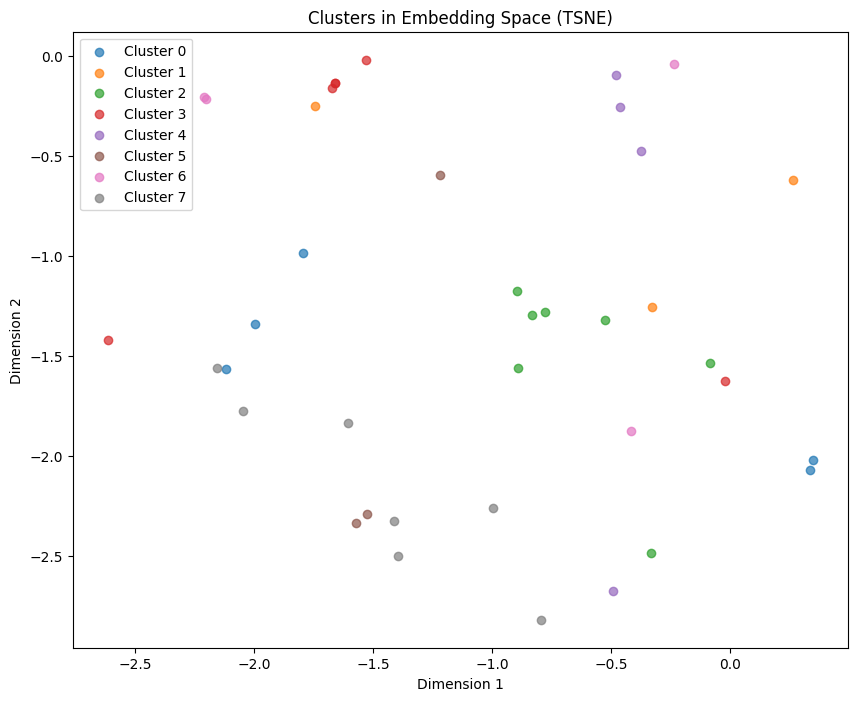

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def visualize_clusters(embeddings, labels, method="tsne"):
    """
    Visualize clusters in embedding space by reducing dimensionality to 2D.
    
    Parameters:
      embeddings (ndarray): shape (N, d) containing the embedding vectors.
      labels (array-like): length N, containing cluster labels for each embedding.
      method (str): either 'tsne' or 'pca' for dimensionality reduction.
    """
    
    # Choose reduction method
    if method.lower() == "tsne":
        reducer = TSNE(n_components=2, random_state=42)
    else:
        reducer = PCA(n_components=2, random_state=42)
    
    # Fit and transform the embeddings to 2D
    reduced = reducer.fit_transform(embeddings)
    
    # Plot with matplotlib
    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(labels)
    for lbl in unique_labels:
        idx = (labels == lbl)
        plt.scatter(
            reduced[idx, 0],
            reduced[idx, 1],
            label=f"Cluster {lbl}",
            alpha=0.7
        )
    
    plt.title(f"Clusters in Embedding Space ({method.upper()})")
    plt.legend()
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

# Example usage:

# Suppose you have embeddings of shape (N, d)
# and an array of labels for each embedding.
# For example (replace with your real data):
# embeddings = np.random.rand(100, 768)  # e.g. 100 vectors of dimension 768
labels = np.array([info["label"] for info in cluster_labels.values()])

visualize_clusters(embeddings, labels[:-2], method="tsne")


## This code visualizes the clusters on the document image

Below is an example that uses matplotlib to display a document image with paragraph bounding boxes drawn and color‐coded by cluster label. In this example, we assume you already have a list of paragraph objects (each with a bounding region containing a polygon) and their corresponding cluster labels. The code computes each paragraph’s bounding box (using the first bounding region) and then overlays a colored rectangle on the image.

---

### Explanation

1. **polygon_to_bbox:**  
   This function takes a list of points (with keys `"x"` and `"y"`) and computes the minimal bounding box coordinates.

2. **plot_paragraph_boxes:**  
   - The image is loaded using OpenCV and converted to RGB.
   - A colormap is generated where each unique cluster label is assigned a random color.
   - For each paragraph, we compute the bounding box from its first bounding region and add a rectangle patch and a text label to the plot.

3. **Example Usage:**  
   We load the OCR JSON, extract paragraphs, generate example cluster labels (replace with your clustering results), and then call the plotting function with the image path.

This approach lets you visualize how paragraphs (and their spatial locations) have been grouped into clusters, with each cluster color-coded on the document image.

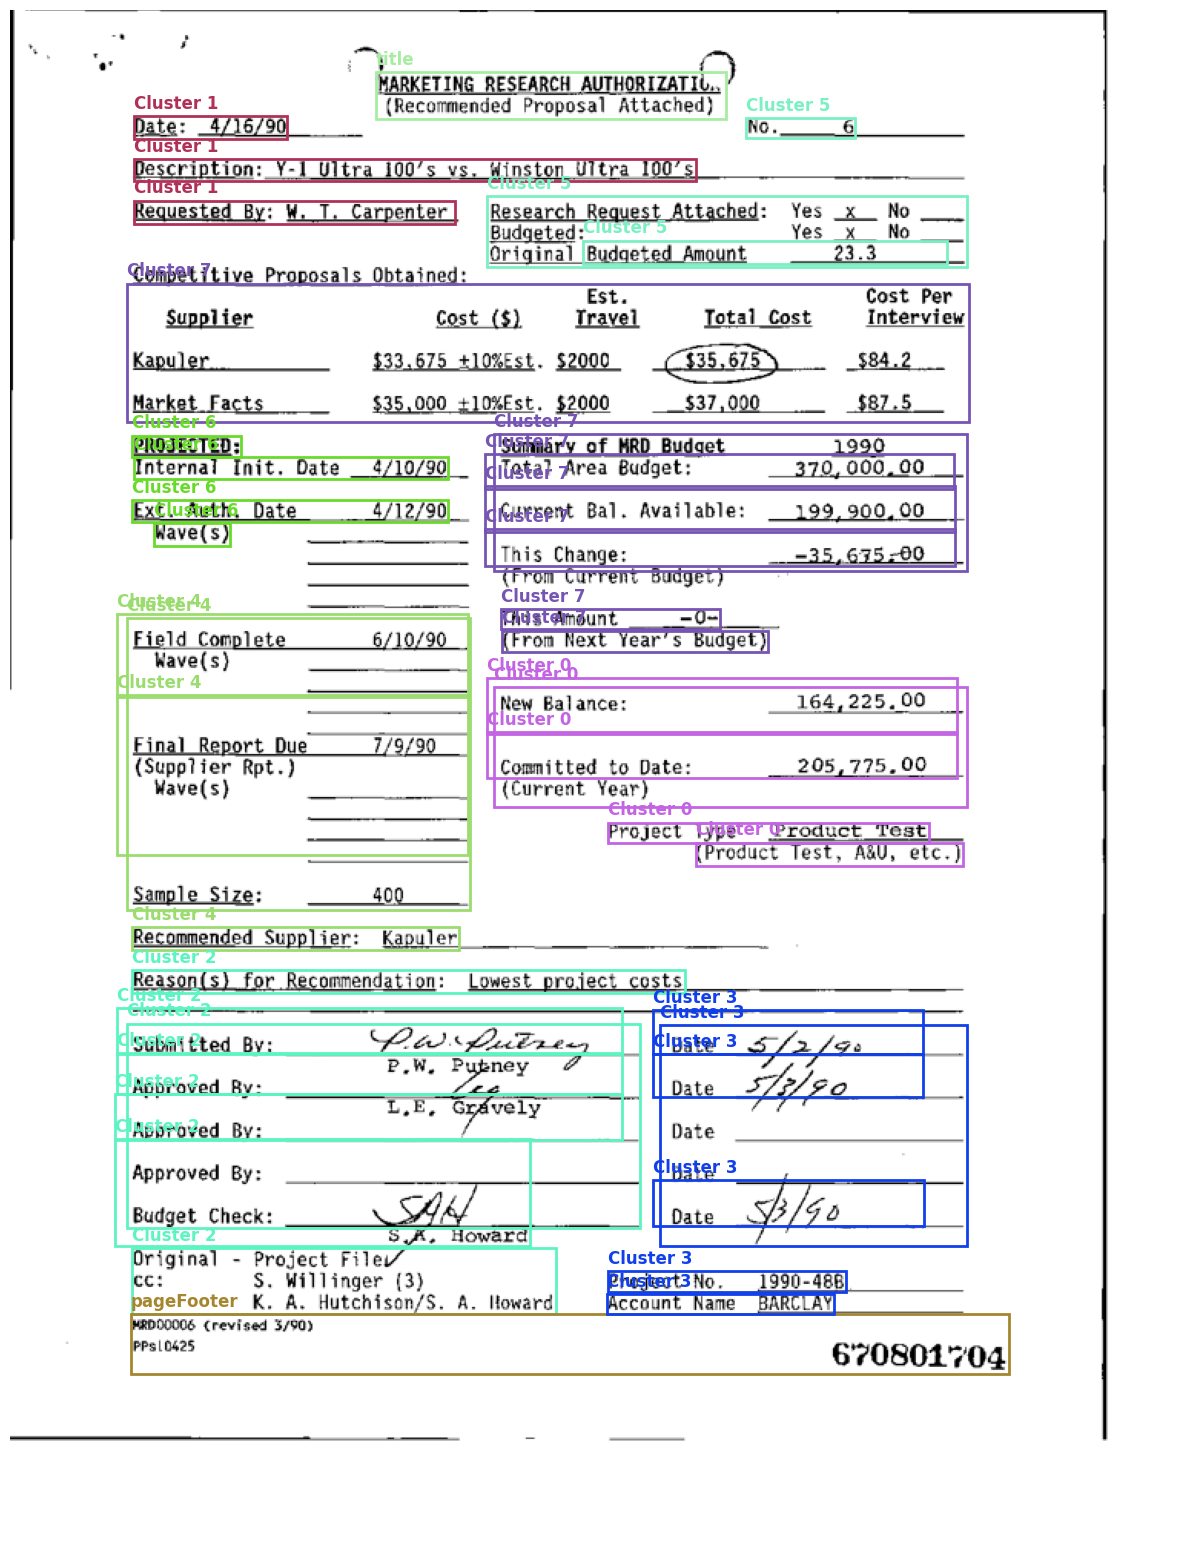

In [137]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from random import randint

def polygon_to_bbox(polygon):
    """
    Given a polygon as a list of points (each point a dict with x, y),
    compute the bounding box [x_min, y_min, x_max, y_max].
    """
    #xs = [pt["x"] for pt in polygon]
    #ys = [pt["y"] for pt in polygon]
    # Assume polygon is a flat list of numbers: [x1, y1, x2, y2, ...]
    pts = np.array(polygon).reshape(-1, 2)
    xs = pts[:, 0]
    ys = pts[:, 1]

    return [min(xs), min(ys), max(xs), max(ys)]

def plot_paragraph_boxes(image_path, paragraphs, labels, clusters=None):
    """
    image_path: path to the document image.
    paragraphs: a list of paragraph objects from OCR data.
      Each paragraph is assumed to have a 'boundingRegions' key containing a list of regions,
      and we use the first region's 'polygon' to compute the bounding box.
    labels: a dictionary of cluster labels corresponding to each paragraph,
            format {pid: {'label': 6, 'name': 'Cluster 6'}
    """
    # Read the image (OpenCV reads as BGR)
    img = cv2.imread(image_path)
    if img is None:
        print("Could not load image.")
        return

    # Convert image to RGB for matplotlib.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create a matplotlib figure
    fig, ax = plt.subplots(1, figsize=(12, 16))
    ax.imshow(img_rgb)

    # Generate a color map for clusters. We'll create one color per unique label.
    # labels is now a dict
    unique_labels = sorted(set([value["label"] for value in labels.values()]))
    cmap = {}
    for lbl in unique_labels:
        # Random color: you can also use a predefined colormap.
        cmap[lbl] = (randint(0,255)/255.0, randint(0,255)/255.0, randint(0,255)/255.0)
    
    # Loop over paragraphs and plot bounding boxes.
    for para in paragraphs:
        # is it valid?
        if para.get("invalid", False):
            continue

        # get label from labels dict by paragraph id
        pid = int(para.get("id", -1))
        if pid < 0:
            continue
        lbl = labels[pid]["label"]
        name = labels[pid]["name"]

        #print(para)
        brs = para.get("boundingRegions", [])
        #print(brs)
        if not brs:
            continue
        # Use the first bounding region for plotting.
        poly = brs[0].get("polygon", [])
        #print(poly)
        if len(poly) < 4:
            continue
        
        bbox = polygon_to_bbox(poly)
        x_min, y_min, x_max, y_max = bbox
        width, height = x_max - x_min, y_max - y_min
        
        # Create a rectangle patch with the cluster color.
        rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2,
                                 edgecolor=cmap[lbl], facecolor='none')
        ax.add_patch(rect)
        # Optionally, add the cluster label as text
        if clusters:
            sem_name = clusters[lbl]["designation"]
            ax.text(x_min, y_min - 5, sem_name, color=cmap[lbl],
                fontsize=12, weight='bold')
        else:
            ax.text(x_min, y_min - 5, name, color=cmap[lbl],
                    fontsize=12, weight='bold')
    
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Example usage:
# Load OCR data (assumed to be a dictionary from your OCR JSON)
#with open("ocr_output.json", "r", encoding="utf-8") as f:
#    ocr_data = json.load(f)

# Extract paragraphs from OCR data. (This assumes a similar structure as provided.)
paragraphs = ocr_data.get("paragraphs", [])

# For demonstration, let's assume you have computed cluster labels for each paragraph.
# For instance, here we assign a random cluster label (in practice, use your clustering results).
#np.random.seed(42)
#labels = [np.random.randint(0, 5) for _ in range(len(paragraphs))]

# Path to your document image
image_path = '../datasets/FUNSD/training_data/images/0001463282.png'

# Plot the bounding boxes with cluster labels.
plot_paragraph_boxes(image_path, paragraphs, cluster_labels, clusters=None)

## This code aggregates the text from paragraphs to the cluster and finds the bounding box/key pairs

Below is an example that assumes you already have your OCR paragraphs (each with a bounding region) and a corresponding list of cluster labels (in the same order as the paragraphs). The code groups paragraphs by cluster label and then sorts the paragraphs within each cluster by their vertical position (using the top coordinate of their bounding box). Finally, it aggregates the text for each cluster in the correct reading order.

---

### How This Code Works

1. **polygon_to_bbox:**  
   Converts a polygon (which may be a flat list of numbers or a list of dictionaries) into a bounding box \([x_{\text{min}}, y_{\text{min}}, x_{\text{max}}, y_{\text{max}}]\).

2. **get_paragraph_top:**  
   Extracts the top (y_min) coordinate from a paragraph’s first bounding region. This value is used for ordering paragraphs vertically.

3. **group_paragraphs_by_cluster:**  
   • First, groups the paragraph objects based on their cluster labels.  
   • Then sorts each group by the vertical position (using `get_paragraph_top`) and optionally by the left coordinate as a tiebreaker.  
   • Finally, it concatenates the text from each paragraph in order, using newline characters.

4. **main:**  
   • Loads the OCR JSON, extracts paragraphs, and uses a simulated clustering assignment (replace with your actual cluster labels).  
   • Then, groups and prints the aggregated text for each cluster.


In [138]:
import json
import numpy as np

def polygon_to_bbox(polygon):
    """
    Convert a flat polygon array into a bounding box [x_min, y_min, x_max, y_max].
    Assumes polygon is a flat list of numbers: [x1, y1, x2, y2, ...].
    """
    pts = np.array(polygon).reshape(-1, 2)
    x_min = float(pts[:, 0].min())
    y_min = float(pts[:, 1].min())
    x_max = float(pts[:, 0].max())
    y_max = float(pts[:, 1].max())
    return [x_min, y_min, x_max, y_max]

def union_bbox(bbox_list):
    """
    Given a list of bounding boxes [x_min, y_min, x_max, y_max],
    return the union bounding box that encloses them all.
    """
    if not bbox_list:
        return None
    xmins = [bbox[0] for bbox in bbox_list]
    ymins = [bbox[1] for bbox in bbox_list]
    xmaxs = [bbox[2] for bbox in bbox_list]
    ymaxs = [bbox[3] for bbox in bbox_list]
    return [min(xmins), min(ymins), max(xmaxs), max(ymaxs)]

def get_paragraph_top(para):
    """
    Return the top (y_min) coordinate from the first bounding region of a paragraph.
    If no bounding region exists, return infinity.
    """
    regions = para.get("boundingRegions", [])
    if not regions:
        return float('inf')
    poly = regions[0].get("polygon", [])
    if not poly:
        return float('inf')
    return polygon_to_bbox(poly)[1]

def group_paragraphs_by_cluster(paragraphs, labels_dict):
    """
    Group paragraphs by cluster and extract the cluster name at the same time.
    
    Parameters:
      paragraphs: List of paragraph objects from OCR JSON.
      labels_dict: Dictionary mapping paragraph id to label info.
    
    Returns:
      A dictionary where keys are cluster labels and values are dicts containing:
         - "name": the cluster name (from labels_dict)
         - "text": concatenated paragraph text in reading order
         - "boundingBox": union bounding box of all paragraphs in the cluster.
    """
    # Create a dictionary mapping cluster labels to {"name": <name>, "paragraphs": [...]}
    cluster_dict = {}
    for para in paragraphs:
        pid = para.get("id", -1)
        if pid in labels_dict:
            label = labels_dict[pid]["label"]
            name = labels_dict[pid]["name"]
            cluster_dict.setdefault(label, {"name": name, "paragraphs": []})
            cluster_dict[label]["paragraphs"].append(para)
    
    # Process each cluster to compute combined text and union bounding box.
    cluster_output = {}
    for lbl, data in cluster_dict.items():
        paras = data["paragraphs"]
        # Sort paragraphs by vertical position, using top coordinate, and x_min as tiebreaker.
        paras_sorted = sorted(
            paras,
            key=lambda p: (
                get_paragraph_top(p),
                polygon_to_bbox(p.get("boundingRegions", [])[0]["polygon"]) if p.get("boundingRegions", []) else [0,0,0,0]
            )
        )
        combined_text = "\n".join(p.get("content", "").strip() for p in paras_sorted)
        # Compute union bounding box using the first bounding region from each paragraph.
        bboxes = []
        for p in paras_sorted:
            if p.get("boundingRegions"):
                bboxes.append(polygon_to_bbox(p["boundingRegions"][0]["polygon"]))
        union_box = union_bbox(bboxes) if bboxes else None
        
        # get key value pairs
        key_pairs = []

        for p in paras_sorted:
            # add in any key pairs in the contributed paragraphs
            key_pairs_p = p.get("key_value_pairs", None)
            if key_pairs_p:
                key_pairs.extend(key_pairs_p)

        cluster_output[lbl] = {
            "name": data["name"],
            "text": combined_text,
            "boundingBox": union_box,
            "key_value_pairs": key_pairs
        }
    return cluster_output

# Load OCR data (this assumes you have an OCR JSON file with a "paragraphs" key)
#with open("ocr_output.json", "r", encoding="utf-8") as f:
#    ocr_data = json.load(f)

paragraphs = ocr_data.get("paragraphs", [])

# Assume you already have computed cluster labels for each paragraph.
# For demonstration, here we simulate labels (replace with your clustering results).
# For example, assign cluster 0 for even indices and 1 for odd indices:
#labels = [0 if i % 2 == 0 else 1 for i in range(len(paragraphs))]

# Group and sort paragraphs by cluster
clusters = group_paragraphs_by_cluster(paragraphs, cluster_labels)

#print(json.dumps(clusters, indent=2))

# Print the aggregated text for each cluster in order.
for cluster_label in sorted(clusters.keys()):
    cluster = clusters[cluster_label]
    print(f"Cluster {cluster_label} ({cluster['name']}):")
    print(cluster['text'])
    print("=" * 80)

print(json.dumps(clusters))

Cluster 0 (Cluster 0):
New Balance: 164,225.00
New Balance:,164,225.00
Committed to Date:,205,775.00
(Current Year),
Committed to Date: 205,775.00
Project Type Product Test
(Product Test, A&U, etc.)
Cluster 1 (Cluster 1):
Date: 4/16/90
Description: Y-1 Ultra 100's vs. Winston Ultra 100's
Requested By: W. T. Carpenter
Cluster 2 (Cluster 2):
Reason(s) for Recommendation: Lowest project costs
Submitted By: P.W. Dutrey
Submitted By:,P.W. Dutrey
Approved By:,P. W. Putney
Approved By:,L. E, Gravely
Approved By:,
Budget Check:,SAN
Approved By: P. W. Putney
Approved By: L. E, Gravely
Approved By: S. R. Howard
Original - Project Filev CC: S. Willinger (3) K. A. Hutchison/S. A. Howard
Cluster 3 (Cluster 3):
Date 5/2/90
,Date,5/2/90
,Date,5/3/90
,Date,
,Date,
,Date,5/3/90
Date 5/3/90
Date 5/3/90
Project No. 1990-488
Account Name BARCLAY
Cluster 4 (Cluster 4):
Wave(s) 6/10/90
Field Complete,6/10/90
Wave(s),
Final Report Due,7/9/90
(Supplier Rpt.) Wave(s),
Sample Size:,400
(Supplier Rpt.) Wave(s) 7

## This code finds positional relationships between clusters within a given margin

Below is a strategy and example Python code to **detect positional relationships** (left, right, above, below, inside, contains) among clusters based on their bounding boxes. The approach:

1. **Iterate** over all pairs of clusters.  
2. **Compare** their bounding boxes for each positional relationship.  
3. **Store** these relationships in a dictionary or adjacency list for easy reference.

This method helps you see how clusters are laid out relative to each other.

---

## 1. Defining Positional Relationships

We’ll assume each cluster has a bounding box in the format \([x_{\min}, y_{\min}, x_{\max}, y_{\max}]\). For two boxes \(b_1\) and \(b_2\), you can check:

1. **Inside**: \(b_1\) is fully inside \(b_2\)  
   \[
   x_{\min}^{(1)} \ge x_{\min}^{(2)},\quad
   y_{\min}^{(1)} \ge y_{\min}^{(2)},\quad
   x_{\max}^{(1)} \le x_{\max}^{(2)},\quad
   y_{\max}^{(1)} \le y_{\max}^{(2)}
   \]
2. **Contains**: \(b_1\) fully contains \(b_2\) (the reverse of inside).  
3. **Left**: \(b_1\) is strictly to the left of \(b_2\) if \(b_1.x_{\max} < b_2.x_{\min}\).  
4. **Right**: \(b_1\) is strictly to the right of \(b_2\) if \(b_1.x_{\min} > b_2.x_{\max}\).  
5. **Above**: \(b_1\) is strictly above \(b_2\) if \(b_1.y_{\max} < b_2.y_{\min}\).  
6. **Below**: \(b_1\) is strictly below \(b_2\) if \(b_1.y_{\min} > b_2.y_{\max}\).

You can also check **overlap** (partial or otherwise) if none of the above “strict separation” conditions hold. Or you can compute the Intersection Over Union (IoU) if you want to see how strongly they overlap.

### Explanation

1. **`bbox_relationship(b1, b2)`**  
   - Checks if `b1` is inside `b2` or contains `b2`.  
   - Checks if `b1` is strictly left/right/above/below `b2`.  
   - If none of these strict separation conditions apply, we check if they overlap by verifying if the bounding boxes intersect.

2. **`compute_cluster_relationships(clusters)`**  
   - Iterates over pairs of clusters.  
   - For each pair `(cid1, cid2)`, obtains bounding boxes `b1` and `b2`.  
   - Calls `bbox_relationship(b1, b2)` and also `bbox_relationship(b2, b1)` to handle directionality (i.e., "contains" vs. "inside").  
   - Stores them in a dictionary keyed by `(cid1, cid2)`.

3. **Example**  
   - The example has three clusters, each with a bounding box. We get a dictionary of relationships describing how cluster 6 relates to 7, how 7 relates to 6, etc.

---

## 2. Interpreting the Relationships

- **Inside vs. Contains**: If bounding box A is inside bounding box B, the reverse will yield “contains.”  
- **Left vs. Right**: If bounding box A is left of bounding box B, then from B’s perspective, A is “right.”  
- **Above vs. Below**: Similar directionality.  
- **Overlaps**: The bounding boxes share positive area but do not strictly satisfy left/right/above/below.  
- **No Relationship**: If a pair doesn’t appear, or you see an empty list in the relationships dictionary, you might interpret that as no direct positional relationship.

You can further adapt the logic to skip “overlaps” if you only care about strictly left, right, etc., or to store multiple relationships. For instance, a bounding box could simultaneously be “overlaps” and “left” if it partially extends to the left side.

---

## 3. Summary

To figure out whether one cluster bounding box is left, right, above, below, inside, or containing another, you:

1. **Compare** bounding box coordinates.
2. **Assign** relationships based on strict numeric conditions.  
3. **Optionally** detect overlap if none of the strict separation relationships hold.  
4. **Store** these relationships for further usage (layout analysis, ordering, adjacency, etc.).

This approach can be extended by adding further checks (e.g., partial overlap metrics, IoU thresholds, etc.) for more nuanced layout logic.

In [144]:
import math

def bbox_relationship(b1, b2, margin):
    """
    Return a list of positional relationships between bounding boxes b1 and b2,
    with a margin/cutoff. Each bounding box is [x_min, y_min, x_max, y_max].
    
    Possible relationships: "inside", "contains", "left", "right", "above", "below", "overlaps".
    
    margin: the distance in pixels/coordinate units to use as a buffer.
    """
    x1_min, y1_min, x1_max, y1_max = b1
    x2_min, y2_min, x2_max, y2_max = b2
    
    relationships = []
    
    # Check inside
    if (x1_min >= x2_min and y1_min >= y2_min and 
        x1_max <= x2_max and y1_max <= y2_max):
        relationships.append("inside")
    
    # Check contains
    if (x2_min >= x1_min and y2_min >= y1_min and 
        x2_max <= x1_max and y2_max <= y1_max):
        relationships.append("contains")
    
    # Check left/right with margin
    # Now b1 is "left" of b2 only if b1.x_max + margin < b2.x_min
    if x1_max + margin < x2_min:
        relationships.append("left")
    
    # b1 is "right" of b2 only if b1.x_min - margin > b2.x_max
    if x1_min - margin > x2_max:
        relationships.append("right")
    
    # Check above/below with margin
    # b1 is "above" b2 if b1.y_max + margin < b2.y_min
    if y1_max + margin < y2_min:
        relationships.append("above")
    
    # b1 is "below" b2 if b1.y_min - margin > b2.y_max
    if y1_min - margin > y2_max:
        relationships.append("below")
    
    # If none of these strict separation conditions applied, we can check "overlaps"
    # or skip if not needed. We'll do a simple bounding box overlap check:
    if not any(r in ["left","right","above","below","contains","inside"] for r in relationships):
        overlap_width = min(x1_max, x2_max) - max(x1_min, x2_min)
        overlap_height = min(y1_max, y2_max) - max(y1_min, y2_min)
        if overlap_width > 0 and overlap_height > 0:
            relationships.append("overlaps")
    
    return relationships

def compute_cluster_relationships(clusters, margin=10):
    """
    clusters is a dict { cluster_id: { "boundingBox": [x_min,y_min,x_max,y_max], ... }, ... }
    Return a dict of form { (cid1, cid2): [list_of_relationships], ... }
    """
    cluster_ids = sorted(clusters.keys())
    rels = {}
    
    for i in range(len(cluster_ids)):
        for j in range(i+1, len(cluster_ids)):
            cid1 = cluster_ids[i]
            cid2 = cluster_ids[j]
            
            b1 = clusters[cid1].get("boundingBox")
            b2 = clusters[cid2].get("boundingBox")
            if b1 and b2:
                r12 = bbox_relationship(b1, b2, margin)
                r21 = bbox_relationship(b2, b1, margin)  # symmetrical but can differ on inside/contains
                rels[(cid1, cid2)] = r12
                rels[(cid2, cid1)] = r21
    
    return rels

# Example usage:

# Suppose we have some cluster dictionary:
# clusters = {
#     6: {
#     "name": "Cluster 6",
#     "boundingBox": [80, 69, 623, 805]
#     },
#     7: {
#     "name": "Cluster 7",
#     "boundingBox": [640, 100, 750, 200]
#     },
#     8: {
#     "name": "Cluster 8",
#     "boundingBox": [90, 70, 100, 120]
#     }
# }

relationships = compute_cluster_relationships(clusters, margin=400)

for (cid1, cid2), rel in relationships.items():
    if rel:
        print(f"Cluster {cid1} => Cluster {cid2}: {rel}")

Cluster 1 => Cluster 2: ['above']
Cluster 2 => Cluster 1: ['below']
Cluster 1 => Cluster 3: ['above']
Cluster 3 => Cluster 1: ['below']
Cluster 1 => Cluster 5: ['overlaps']
Cluster 5 => Cluster 1: ['overlaps']
Cluster 1 => Cluster 8: ['overlaps']
Cluster 8 => Cluster 1: ['overlaps']
Cluster 1 => Cluster 9: ['above']
Cluster 9 => Cluster 1: ['below']
Cluster 2 => Cluster 3: ['overlaps']
Cluster 3 => Cluster 2: ['overlaps']
Cluster 2 => Cluster 5: ['below']
Cluster 5 => Cluster 2: ['above']
Cluster 2 => Cluster 8: ['below']
Cluster 8 => Cluster 2: ['above']
Cluster 3 => Cluster 5: ['below']
Cluster 5 => Cluster 3: ['above']
Cluster 3 => Cluster 8: ['below']
Cluster 8 => Cluster 3: ['above']
Cluster 4 => Cluster 7: ['overlaps']
Cluster 7 => Cluster 4: ['overlaps']
Cluster 5 => Cluster 8: ['overlaps']
Cluster 8 => Cluster 5: ['overlaps']
Cluster 5 => Cluster 9: ['above']
Cluster 9 => Cluster 5: ['below']
Cluster 6 => Cluster 7: ['inside']
Cluster 7 => Cluster 6: ['contains']
Cluster 6 => C

## This code finds the reading order of the clusters

Below is a straightforward method to **sort clusters in reading order**: top to bottom, then left to right for ties. Essentially, we:

1. **Extract** each cluster’s bounding box.  
2. **Sort** primarily by the top (\(y_{\min}\)) coordinate.  
3. **Tiebreak** clusters with similar \(y_{\min}\) by their left (\(x_{\min}\)) coordinate.

This approach is commonly used in document layout analysis (e.g., reading lines). 

---

## 2. Optional Variations

- **Tolerance / Margin**: If you want a small tolerance for lines that share nearly the same \(y_{\min}\), you might group them together before sorting left to right, or skip to left–right if \(|y_{\min,1} - y_{\min,2}| < \epsilon\). 
- **Center vs. Top**: Some layouts require sorting by the bounding box center \( (y_{\text{center}}) \) or baseline. For a typical top–down reading, using `y_min` is a good start. 
- **Multiple Lines**: If you have multi-line clusters, you might segment them further. But for a single bounding box per cluster, this is typically enough.

---

## 3. Summary

The key for a top–down, left–right reading order is:

- **Primary Sort**: By \(y_{\min}\) ascending (lowest means top).  
- **Secondary Sort**: By \(x_{\min}\) ascending (lowest means left).  

This yields a reading order that approximates how most Western-language text is read, especially if each cluster corresponds to a line or block of content.

In [145]:
def sort_clusters_reading_order(clusters):
    """
    Sorts clusters in a reading order: top to bottom, then left to right.
    Clusters is a dict keyed by cluster_id, each with "boundingBox": [x_min,y_min,x_max,y_max].
    
    Returns a list of (cluster_id, cluster_info) in sorted order.
    """
    # Convert clusters dict items to a list for sorting
    cluster_items = list(clusters.items())
    
    def reading_key(item):
        cid, cinfo = item
        bbox = cinfo.get("boundingBox", [0,0,0,0])
        x_min, y_min, x_max, y_max = bbox
        return (y_min, x_min)  # Sort by top edge, then left edge
    
    # Sort by y_min ascending, then x_min ascending
    cluster_sorted = sorted(cluster_items, key=reading_key)
    return cluster_sorted

# Example usage:
# Suppose we have a cluster dict:
# clusters = {
#     6: { "name": "Cluster 6", "boundingBox": [80, 69, 623, 805] },  # (x_min=80, y_min=69)
#     7: { "name": "Cluster 7", "boundingBox": [100, 200, 200, 300] }, # (x_min=100, y_min=200)
#     8: { "name": "Cluster 8", "boundingBox": [90, 180, 190, 190] },  # (x_min=90, y_min=180)
#     9: { "name": "Cluster 9", "boundingBox": [50, 180, 100, 190] },  # (x_min=50, y_min=180)
# }

sorted_clusters = sort_clusters_reading_order(clusters)
for cid, cinfo in sorted_clusters:
    print(f"Cluster {cid} => boundingBox={cinfo['boundingBox']}, name={cinfo['name']}")

Cluster 8 => boundingBox=[238.0, 40.0, 466.0, 71.0], name=title
Cluster 1 => boundingBox=[80.0, 69.0, 446.0, 139.0], name=Cluster 1
Cluster 5 => boundingBox=[310.0, 70.0, 623.0, 167.0], name=Cluster 5
Cluster 7 => boundingBox=[76.0, 178.0, 624.0, 418.0], name=Cluster 7
Cluster 6 => boundingBox=[79.0, 277.0, 285.0, 349.0], name=Cluster 6
Cluster 4 => boundingBox=[69.0, 393.0, 299.0, 612.0], name=Cluster 4
Cluster 0 => boundingBox=[310.0, 435.0, 623.0, 557.0], name=Cluster 0
Cluster 2 => boundingBox=[68.0, 625.0, 439.0, 849.0], name=Cluster 2
Cluster 3 => boundingBox=[388.0, 651.0, 623.0, 849.0], name=Cluster 3
Cluster 9 => boundingBox=[78.0, 849.0, 650.0, 888.0], name=pageFooter


## This code ust GPT to generate the Semantic Designation (e.g., “Title”, “Introduction”, “Methodology”, “Results”, “Conclusion”)

Below is an example Python script that sends each cluster’s aggregated text to GPT‑4 via the OpenAI API and asks for a semantic designation (e.g., “Title”, “Introduction”, “Methodology”, “Results”, “Conclusion”) for that cluster. The code assumes you already have a dictionary mapping cluster labels to their combined text. You can adjust the prompt and parameters as needed.

### How It Works

1. **get_semantic_designation Function:**  
   - This function builds a prompt that instructs GPT‑4 to assign a semantic designation to the provided cluster text.
   - It uses `openai.ChatCompletion.create` with a system message (setting context) and a user message (with the prompt).
   - The function extracts and returns the semantic designation from GPT‑4's response.

2. **Main Function:**  
   - We assume a dictionary `clusters` where keys are cluster IDs and values are the aggregated text of each cluster.
   - For each cluster, the script calls `get_semantic_designation` and prints the result.
   - Finally, it saves the designations to a JSON file.

3. **Customization:**  
   - Adjust the prompt if you need different instructions.
   - Change the temperature or max_tokens to tweak response style and length.
   - Replace the demo `clusters` dictionary with your actual clustered data.

This script provides a complete pipeline to have GPT‑4 determine the semantic designation for each text cluster extracted from your document.

In [132]:
from openai import OpenAI
import json
import os

# Make sure your OpenAI API key is set in your environment:
# export OPENAI_API_KEY="your_api_key_here"

def get_semantic_designation(cluster_text):
    """
    Uses GPT‑4 via ChatCompletion to determine a semantic designation for the given cluster text.
    Returns the designation as a string.
    """
    prompt = (
        "You are a helpful assistant that assigns a semantic designation to a document text cluster. "
        "Based on the text provided, please output a one- or two-word designation that best describes "
        "the key concept of the text (for example: 'Title', 'Introduction', 'Methodology', 'Results', "
        "'Conclusion', etc.).\n\n"
        "Cluster Text:\n" + cluster_text + "\n\n"
        "Semantic Designation:"
    )

    client = OpenAI(
        api_key=os.environ.get("OPENAI_API_KEY"),  # This is the default and can be omitted
    )
    
    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": "You are an expert in document analysis."},
            {"role": "user", "content": prompt}
        ],
        model="gpt-4o",
        temperature=0.3,
        max_tokens=30
    )
    
    # Extract the generated designation from the response.
    designation = response.choices[0].message.content.strip()
    return designation

# ask GPT for its opinion on semantic designation and add to clusters
for label, cluster in clusters.items():
    # run semantic designation 
    designation = get_semantic_designation(cluster["text"])
    cluster["designation"] = designation
    print(f"Cluster {label} ({cluster['name']}) is designated as: {designation}\n")

# print results
#print(json.dumps(clusters, indent=2))


Cluster 8 (title) is designated as: Authorization

Cluster 1 (Cluster 1) is designated as: Comparison

Cluster 6 (Cluster 6) is designated as: 'Timeline'

Cluster 7 (Cluster 7) is designated as: Budget Analysis

Cluster 0 (Cluster 0) is designated as: Financial Summary

Cluster 2 (Cluster 2) is designated as: Approval

Cluster 9 (pageFooter) is designated as: Identifier

Cluster 5 (Cluster 5) is designated as: Budget

Cluster 4 (Cluster 4) is designated as: Timeline

Cluster 3 (Cluster 3) is designated as: Metadata



## This code visualizes the clusters on the document image.

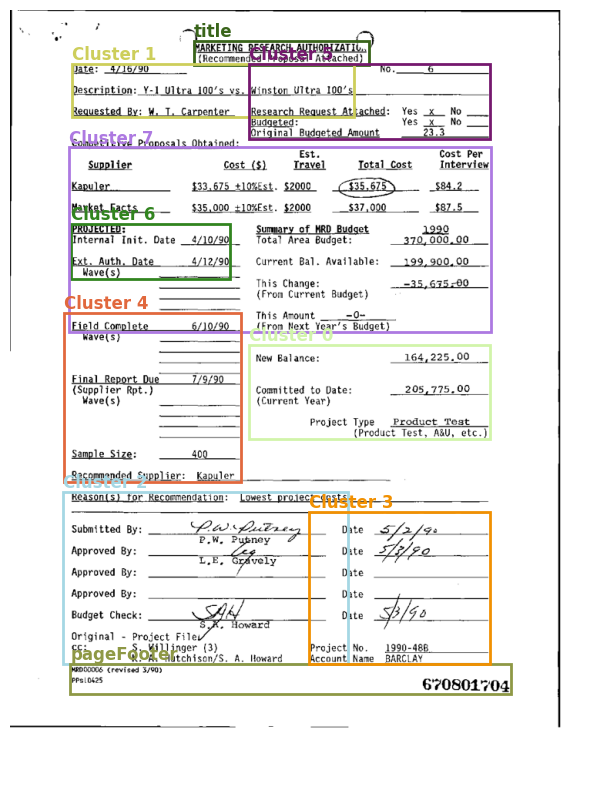

In [133]:
import cv2
import matplotlib.pyplot as plt
import random

def plot_cluster_bboxes(image_path, clusters):
    """
    Plot the cluster bounding boxes on the image.
    
    Parameters:
      image_path: Path to the main image.
      clusters: A dictionary of clusters where each cluster has a "boundingBox"
                key in the form [x_min, y_min, x_max, y_max] and a "name".
    """
    # Load the image (OpenCV loads in BGR)
    image = cv2.imread(image_path)
    if image is None:
        print("Error loading image")
        return
    # Convert image to RGB for plotting
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Create a matplotlib figure
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image_rgb)
    
    # For each cluster, draw the bounding box with a random color.
    for label, cluster in clusters.items():
        bbox = cluster.get("boundingBox")
        name = cluster.get("name", f"Cluster {label}")
        if bbox:
            x_min, y_min, x_max, y_max = bbox
            width = x_max - x_min
            height = y_max - y_min
            
            # Generate a random color
            color = (random.random(), random.random(), random.random())
            
            # Create a rectangle patch
            rect = plt.Rectangle((x_min, y_min), width, height, fill=False, color=color, linewidth=2)
            ax.add_patch(rect)
            
            # Annotate with the cluster name
            ax.text(x_min, y_min - 5, name, fontsize=12, color=color, weight="bold")
    
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Example usage:
# Path to the main image
image_path = "../datasets/FUNSD/training_data/images/0001463282.png"  # update to your image path

plot_cluster_bboxes(image_path, clusters)

---

# This Section extracts the key-concepts/relationships from the Clusters

---

# KAG Extraction Code Documentation
Code based on Chuck Vardeman's `Funsd_Lexical_Graph.ipynb` notebook.

## Overview

### Notes
Very early version using Cosette.

**KAG Extraction** refers to the process of extracting groups of related key–value pairs and their associated data from documents. Many structured documents (e.g., forms, invoices, reports) organize information in key–value pairs grouped together. KAG extraction leverages both the textual content and the document’s layout (bounding boxes, spatial relationships) to identify and extract these groups in a structured format.

This code implements a KAG extraction pipeline that:
- Reads the OCR output from a document.
- Groups paragraphs (and optionally other elements) into clusters based on predefined labels.
- Aggregates the text and computes a union bounding box for each cluster.
- Associates key–value pairs with the corresponding clusters based on referenced paragraph IDs.
- (Optionally) Processes images by cropping regions corresponding to cluster bounding boxes.

## What Is KAG Extraction?

- **Key-Attribute Groups (KAGs):**  
  In many documents, information is presented as key–value pairs (e.g., "Date: 4/16/90"). KAG extraction identifies these groups and consolidates their data.

- **Layout-Driven Processing:**  
  By leveraging the geometric information (bounding boxes or polygons) provided by the OCR output, KAG extraction helps determine which text elements belong together.

- **Benefits:**  
  - **Improved accuracy:** Using layout cues helps to associate related information.
  - **Structured data:** It produces a structured output (e.g., clusters, merged paragraphs) that’s easier to process downstream.
  - **Extensibility:** The pipeline can be extended to handle additional elements (like tables with key–value pairs) and to interface with external services for further processing.

## Code Breakdown

### 1. Importing Libraries

The code imports necessary modules for:
- **File and JSON operations:** `os` and `json`
- **Numerical computations:** `numpy`
- (Optionally) **Image processing:** OpenCV (`cv2`) if working with images

### 2. Helper Functions

- **`polygon_to_bbox(polygon)`**  
  Converts a flat list of polygon coordinates (e.g., `[x1, y1, x2, y2, ...]`) into a bounding box of the form `[x_min, y_min, x_max, y_max]`.

- **`union_bbox(bbox_list)`**  
  Computes the union of multiple bounding boxes—i.e., a single bounding box that covers all provided boxes.

- **`bbox_to_polygon(bbox)`**  
  Converts a bounding box into a full polygon format with eight numbers (representing the four corners in order).

- **`get_paragraph_top(para)`**  
  Extracts the top coordinate (y_min) from a paragraph’s first bounding region. This is used to sort paragraphs in reading order.

### 3. Grouping Paragraphs by Cluster

The function `group_paragraphs_by_cluster(paragraphs, labels_dict)` performs the following:
- **Grouping:**  
  It loops over each paragraph in the OCR output and uses a provided `labels_dict` (which maps paragraph IDs to cluster label and name) to group paragraphs by their cluster.
  
- **Extracting Cluster Names:**  
  While grouping, the code extracts the cluster name (e.g., "Cluster 7") from the `labels_dict` so that the final output for each cluster includes both the cluster label and name.

- **Sorting and Aggregation:**  
  Within each cluster, paragraphs are sorted by their vertical position (using `get_paragraph_top`) and optionally by their left coordinate. The texts of the sorted paragraphs are concatenated, and their bounding boxes are unioned to produce a single bounding box for the cluster.

### 4. Adding Key–Value Pairs to Clusters

The function `add_key_value_pairs_to_clusters(ocr_data, clusters, labels_dict)`:
- Builds a mapping from paragraph IDs to cluster labels.
- Iterates over each key–value pair in the OCR JSON.
- For each key–value pair, it examines the referenced paragraphs (via `"elements"` pointers) and determines which cluster they belong to.
- It then adds the key–value pair to that cluster’s data under a new key (e.g., `"keyValuePairs"`).

### 5. (Optional) Image Processing

Additional functions (like `crop_with_margin` and `image_to_base64`) can be integrated to:
- Crop the main image using a cluster’s bounding box with added margins.
- Convert the cropped image to a base64-encoded string to send to external APIs (e.g., Cosette or OpenAI).

## How the Code Works Together

1. **OCR Extraction:**  
   The OCR system outputs a JSON containing paragraphs, tables, key–value pairs, etc., along with layout information.

2. **Grouping and Aggregation:**  
   The code groups paragraphs by their cluster labels (from `labels_dict`), sorts them in reading order, concatenates their text, and computes a union bounding box for each cluster.

3. **Key–Value Association:**  
   The code then associates any key–value pairs with the clusters based on which paragraphs they reference.

4. **Output:**  
   The final output is a dictionary mapping each cluster label to:
   - A cluster name.
   - Aggregated text.
   - A union bounding box.
   - A list of associated key–value pairs.

## Conclusion

KAG extraction leverages both document layout and text content to structure data into meaningful clusters. This code demonstrates a pipeline for grouping paragraphs, aggregating their content, computing union bounding boxes, and associating key–value pairs—all of which can be used for further semantic analysis or to supply context to external APIs.

In [10]:
from cosette import *
from toolslm.md_hier import *

model = models[2]
model

'gpt-4o'

In [11]:
# First redefine our parse_json function with the new improvements
def parse_json(s: str) -> dict:
    "Parse JSON from raw LLM response, handling markdown code blocks"
    if isinstance(s, (dict,list)): return s
    if hasattr(s, 'choices'): s = s.choices[0].message.content
    
    # Extract JSON from markdown code block if present
    if '```' in s:
        blocks = s.split('```')
        # Take the content between ```json and ```
        for i, block in enumerate(blocks):
            if block.strip().lower() == 'json' and i+1 < len(blocks):
                s = blocks[i+1]
                break
    
    # Clean up and parse
    s = s.strip()
    if not s.startswith('{'): s = s[s.find('{'):]
    if not s.endswith('}'): s = s[:s.rfind('}')+1]
    return json.loads(s)

In [12]:
import cv2
import base64

def crop_with_margin(image, bbox, margin=10):
    """
    Crop the image using the provided bounding box with an added margin.
    
    Parameters:
      image: The main image as a NumPy array.
      bbox: List or tuple in the form [x_min, y_min, x_max, y_max].
      margin: Number of pixels to add as a margin around the bbox.
    
    Returns:
      The cropped image as a NumPy array.
    """
    x_min, y_min, x_max, y_max = bbox
    h, w = image.shape[:2]
    
    # Expand the bounding box by margin and clip to image dimensions.
    x_min = max(0, int(x_min) - margin)
    y_min = max(0, int(y_min) - margin)
    x_max = min(w, int(x_max) + margin)
    y_max = min(h, int(y_max) + margin)
    
    return image[y_min:y_max, x_min:x_max]

def image_to_base64(image, ext=".png"):
    """
    Convert an OpenCV image to a base64-encoded string.
    
    Parameters:
      image: The image as a NumPy array.
      ext: File extension for encoding (default is ".jpg").
      
    Returns:
      A string in the format "data:image/jpeg;base64,..." ready for transmission.
    """
    # Encode the image to the chosen format
    success, buffer = cv2.imencode(ext, image)
    if not success:
        raise ValueError("Image encoding failed")
    
    # Convert the buffer to base64
    img_base64 = base64.b64encode(buffer).decode('utf-8')
    # Build a data URI (this is one common format)
    data_uri = f"data:image/jpeg;base64,{img_base64}"
    return data_uri


In [23]:
def test_kag_region_extraction(region, img):
    "Extract content from a specific region"
    example = {
        "content": "exact text as it appears",
        "concepts": [{
            "type": "concept type (e.g. role, identity, contact)",
            "value": "extracted concept"
        }],
        "document_purpose": "how this content serves the document",
        "relationships": [{
            "type": "relationship type",
            "target": "related document part",
            "description": "nature of relationship"
        }]
    }
    
    prompt = f"""<context>
    Region: {region["name"]} ({region["designation"]})
    Position: {region["boundingBox"]}
    Text: {region["text"]}
    Key-Value Pairs: {region.get("key_value_pairs", "None")}
    </context>

    You are an expert in document layout analysis with a focus on extracting key concepts and identifying relationships between document elements. Analyze the above region and determine:
    - The primary content and any significant concepts (e.g., roles, identities, contacts).
    - How this region contributes to the overall purpose of the document.
    - Any relationships among elements within this region, especially using the provided key–value pairs if available.

    Return your analysis as a JSON object exactly matching this structure:
    {json.dumps(example, indent=2)}

    Return ONLY the JSON object."""
    #print(prompt)
    chat = Chat(model, sp="""You are a helpful and concise assistant with ontology experience.""")
    result = parse_json(chat([img, prompt]))
    return dict(result)

def test_region(region_idx=0):
    "Test region content extraction with clean output"
    try:
        print(f"Testing region {region_idx} extraction...")
        print("="*50)
        
        # Get layout and specified region
        # Load your main image
        image_path = "../datasets/FUNSD/training_data/images/0001463282.png"  # Replace with your image path
        image = cv2.imread(image_path)
        
        cluster = clusters[region_idx]
        #print(cluster)
        # Example cluster bounding box [x_min, y_min, x_max, y_max]
        cluster_bbox = cluster["boundingBox"]
    
        # Crop the image with a 20-pixel margin.
        cropped = crop_with_margin(image, cluster_bbox, margin=20)

        # Save the cropped image (or process it further)
        cv2.imwrite("cropped_cluster.png", cropped)
        #print("Cropped image saved as 'cropped_cluster.png'.")
        with open("cropped_cluster.png", "rb") as f:
            image_bytes = f.read()

        print(f"Analyzing {cluster['name']} ({cluster['designation']}) region...")
        result = test_kag_region_extraction(cluster, image_bytes)  # Now passing region parameter
        
        #print(result)
        
        print("\nValidation:")
        print("="*50)
        print(f"Content length: {len(result['content'])}")
        print(f"Number of concepts: {len(result['concepts'])}")
        print(f"Number of relationships: {len(result['relationships'])}")
        
        return result
        
    except Exception as e:
        print(f"Error during testing: {str(e)}")
        return None

# Let's try it
results = []
for indx in range(len(clusters)):
    print("Analyzing Cluster", indx)
    result = test_region(indx)
    results.append(result)

Analyzing Cluster 0
Testing region 0 extraction...
Analyzing Cluster 0 (Budget Analysis) region...

Validation:
Content length: 471
Number of concepts: 6
Number of relationships: 2
Analyzing Cluster 1
Testing region 1 extraction...
Analyzing Cluster 1 (Identification) region...

Validation:
Content length: 41
Number of concepts: 2
Number of relationships: 1
Analyzing Cluster 2
Testing region 2 extraction...
Analyzing Cluster 2 (Budget Information) region...

Validation:
Content length: 92
Number of concepts: 4
Number of relationships: 2
Analyzing Cluster 3
Testing region 3 extraction...
Analyzing Cluster 3 ('Timeline') region...

Validation:
Content length: 70
Number of concepts: 2
Number of relationships: 1
Analyzing Cluster 4
Testing region 4 extraction...
Analyzing Cluster 4 (Data Collection) region...

Validation:
Content length: 144
Number of concepts: 4
Number of relationships: 3
Analyzing Cluster 5
Testing region 5 extraction...
Analyzing Cluster 5 (Financial Summary) region...


## Analyze complete document, given all extracted information, to look for concepts/relationships across the document.

In [53]:
import json

def extract_key_value_text(ocr_json):
    """
    Extract key and value text from each keyValuePair in the OCR JSON.
    Returns a list of dictionaries with "key" and "value".
    """
    kv_list = []
    for kv in ocr_json.get("keyValuePairs", []):
        key_text = kv.get("key", {}).get("content", "").strip()
        value_text = kv.get("value", {}).get("content", "").strip()
        kv_list.append({
            "key": key_text,
            "value": value_text
        })
    return kv_list

def kag_all_extraction(region_analysis, keyValuePairs, document_text, img):
    "Extract additional content based on entire document"
    example = {
        "content": "exact text as it appears",
        "concepts": [{
            "type": "concept type (e.g. role, identity, contact)",
            "value": "extracted concept"
        }],
        "document_purpose": "how this content serves the document",
        "relationships": [{
            "type": "relationship type",
            "target": "related document part",
            "description": "nature of relationship"
        }]
    }
    
    prompt = f"""<global_context>
    Entire Document Text:
    {document_text}

    Extraction Results:
    {json.dumps(region_analysis, indent=2)}

    Key-Value Pairs:
    {json.dumps(keyValuePairs, indent=2)}

    Main Image: [Provide a URL or description of the full image]
    </global_context>

    You are an expert in document layout and semantic analysis. Based on the global context above—which includes the full document text, the combined extraction results and the complete list of key–value pairs—perform a comprehensive analysis of the document. In particular:
    - Identify any additional concepts and relationships that may not have been captured in the initial extraction.
    - Leverage the key–value pairs as additional cues to uncover associations (for example, linking a date with an event or amount).

    Return your analysis as a JSON object matching the following structure:
    {json.dumps(example, indent=2)}
 
    Return ONLY the JSON object.
    """
    
    #print(prompt)

    chat = Chat(model, sp="""You are a helpful and concise assistant with ontology experience.""")
    result = parse_json(chat([img, prompt]))
    return dict(result)

# Load your main image
image_path = "../datasets/FUNSD/training_data/images/0001463282.png"  # Replace with your image path
with open(image_path, "rb") as f:
    image_bytes = f.read()

# Load your OCR JSON (update file path as necessary)
with open('../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged_new_kp-table.json', "r", encoding="utf-8") as f:
    ocr_data = json.load(f)
    extracted = extract_key_value_text(ocr_data)
    content = ocr_data.get("content", "")
    #print(content)

result_all = kag_all_extraction(results, extracted, content, image_bytes)

print("\nValidation:")
print("="*50)
print(f"Content length: {len(result_all['content'])}")
print(f"Number of concepts: {len(result_all['concepts'])}")
print(f"Number of relationships: {len(result_all['relationships'])}")

# Append to cluster data
results.append(result_all)


Validation:
Content length: 1291
Number of concepts: 22
Number of relationships: 5


In [54]:
result_all

{'content': "MARKETING RESEARCH AUTHORIZATIU .. (Recommended Proposal Attached)\nDate: 4/16/90\nDescription: Y-1 Ultra 100's vs. Winston Ultra 100's\nRequested By: W. T. Carpenter\nResearch Request Attached: Yes X No\nBudgeted: Yes X No\nOriginal Budgeted Amount 23.3\nCompetitive Proposals Obtained: Supplier, Cost ($), Est. Travel, Total Cost, Cost Per Interview\nKapuler, $33,675 +10%Est., $2000, $35,675, $84.2\nMarket Facts, $35,000 +10%Est., $2000, $37,000, $87.5\nPROJECTED:\nInternal Init. Date, 4/10/90\nExt. Auth. Date\nWave(s), 4/12/90\nSummary of MRD Budget\n1990 Total Area Budget, 370,000.00\nCurrent Bal. Available, 199,900.00\nThis Change, -35,675.00\n(From Current Budget)\nThis Amount, -0-\n(From Next Year's Budget)\nField Complete\nWave(s), 6/10/90\nFinal Report Due\n(Supplier Rpt.) Wave(s), 7/9/90\nSample Size, 400\nNew Balance, 164,225.00\nCommitted to Date, 205,775.00\nProject Type, Product Test\nRecommended Supplier, Kapuler\nReason(s) for Recommendation, Lowest project c

## Ontologize?

In [111]:
import json

def extract_key_value_text(ocr_json):
    """
    Extract key and value text from each keyValuePair in the OCR JSON.
    Returns a list of dictionaries with "key" and "value".
    """
    kv_list = []
    for kv in ocr_json.get("keyValuePairs", []):
        key_text = kv.get("key", {}).get("content", "").strip()
        value_text = kv.get("value", {}).get("content", "").strip()
        kv_list.append({
            "key": key_text,
            "value": value_text
        })
    return kv_list

def Tbox_Abox_extraction(region_analysis, keyValuePairs, document_text, clusters, img):
    "Extract additional content based on entire document"
        
    prompt = f"""<context>
    Entire Document Text:
    {document_text}

    Clusters:
    {json.dumps(clusters, indent=2)}

    </context>

    You are a narrative-focused assistant. Below are factual data points extracted 
    from a document that was broken down into semantic clusters. Please write a story
    that includes all the details and concepts and illustrates their relationships:
    {json.dumps(region_analysis, indent=2)}

    In your story, ensure you address all relationships, especially those related to the key-value pairs:
    {json.dumps(keyValuePairs, indent=2)}

    For reference we include the complete document text:
    {document_text}

    Ensure that all numeric values, names, tables, dates organizations must be represented in the scenario.

    Return your short narrative, focusing on the relationships among these data points.
    In addition identify key concepts and relationships.
    """
    
    #print(prompt)

    chat = Chat(model, sp="""You are a helpful and assistant with ontology experience.""")
    result = chat([img, prompt])
    return result

# Load your main image
image_path = "../datasets/FUNSD/training_data/images/0001463282.png"  # Replace with your image path
with open(image_path, "rb") as f:
    image_bytes = f.read()

# Load your OCR JSON (update file path as necessary)
with open('../datasets/FUNSD/training_data/annotations_new/0001463282_prebuilt_layout_merged_new_kp-table.json', "r", encoding="utf-8") as f:
    ocr_data = json.load(f)
    extracted = extract_key_value_text(ocr_data)
    content = ocr_data.get("content", "")
    #print(extracted)

Tbox_Abox = Tbox_Abox_extraction(results, extracted, content, clusters, image_bytes)



In [112]:
Tbox_Abox

In the bustling office of Barclay Marketing, April 16, 1990, was a significant day. The company was about to embark on a comparative marketing research project titled "Y-1 Ultra 100's vs. Winston Ultra 100's." The request for this ambitious endeavor was put forth by W. T. Carpenter, and it was marked as document No. 6 in their series of investigative efforts.

Attached to this venture was a research request marked as budgeted, with an initial allocation set at 23.3 thousand dollars. The company sought competitive proposals to execute this project effectively, with suppliers Kapuler and Market Facts emerging as key contenders. Kapuler proposed a total cost of $35,675, inclusive of estimated travel expenses, with a cost per interview landing at $84.2. Their competitor, Market Facts, came in slightly higher at a total of $37,000 and a cost per interview of $87.5.

Kapuler had the clear edge, being recommended as the supplier due to their lower project costs—a decision documented and officially submitted by P.W. Dutrey. This choice underwent rigorous approval, receiving nods from notable figures like P. W. Putney and L. E. Gravely, finally securing a budget check from S. R. Howard by May 3, 1990.

Throughout this process, the financial and logistical details were meticulously recorded. Barclay's 1990 total area budget was a substantial $370,000, with a current balance of $199,900. Adjustments accounted for the anticipated expenditure of $35,675, reducing the balance to $164,225. The project, categorized as a product test, earmarked the field completion for June 10, 1990, with a final report due by July 9. A sample size of 400 ensured robust findings, aligning with the company's commitment to thorough research and reliable conclusions.

This initiative was not just a collection of statistics and figures; it represented a strategic move in the competitive landscape. It was intricately connected to the project's identity—Project No. 1990-488, nestled under the account name BARCLAY. Essential internal communications were facilitated by S. Willinger, K. A. Hutchison, and S. A. Howard, ensuring that every detail followed due diligence.

This document, coded MRD00006, served as both a blueprint and a testament to Barclay's dedication to precision, competition, and market insight in the research arena.

**Key Concepts and Relationships:**

- **Concepts:**
  - Research Project: Y-1 Ultra 100's vs. Winston Ultra 100's
  - Suppliers: Kapuler, Market Facts
  - Budget: Total costs, Cost per interview
  - Approval Process: Submitted, approved by key personnel

- **Relationships:**
  - Financial Allocation: Linking budget to project execution
  - Supplier Evaluation: Cost comparison leading to Kapuler's selection
  - Timeline Management: Specified project milestones and deadlines
  - Documentation and Approval: Comprehensive process with multiple checks and balances

<details>

- id: chatcmpl-B4IbZu7nJQVg4pGt1oFPNMnlLaW9v
- choices: [Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='In the bustling office of Barclay Marketing, April 16, 1990, was a significant day. The company was about to embark on a comparative marketing research project titled "Y-1 Ultra 100\'s vs. Winston Ultra 100\'s." The request for this ambitious endeavor was put forth by W. T. Carpenter, and it was marked as document No. 6 in their series of investigative efforts.\n\nAttached to this venture was a research request marked as budgeted, with an initial allocation set at 23.3 thousand dollars. The company sought competitive proposals to execute this project effectively, with suppliers Kapuler and Market Facts emerging as key contenders. Kapuler proposed a total cost of $35,675, inclusive of estimated travel expenses, with a cost per interview landing at $84.2. Their competitor, Market Facts, came in slightly higher at a total of $37,000 and a cost per interview of $87.5.\n\nKapuler had the clear edge, being recommended as the supplier due to their lower project costs—a decision documented and officially submitted by P.W. Dutrey. This choice underwent rigorous approval, receiving nods from notable figures like P. W. Putney and L. E. Gravely, finally securing a budget check from S. R. Howard by May 3, 1990.\n\nThroughout this process, the financial and logistical details were meticulously recorded. Barclay\'s 1990 total area budget was a substantial $370,000, with a current balance of $199,900. Adjustments accounted for the anticipated expenditure of $35,675, reducing the balance to $164,225. The project, categorized as a product test, earmarked the field completion for June 10, 1990, with a final report due by July 9. A sample size of 400 ensured robust findings, aligning with the company\'s commitment to thorough research and reliable conclusions.\n\nThis initiative was not just a collection of statistics and figures; it represented a strategic move in the competitive landscape. It was intricately connected to the project\'s identity—Project No. 1990-488, nestled under the account name BARCLAY. Essential internal communications were facilitated by S. Willinger, K. A. Hutchison, and S. A. Howard, ensuring that every detail followed due diligence.\n\nThis document, coded MRD00006, served as both a blueprint and a testament to Barclay\'s dedication to precision, competition, and market insight in the research arena.\n\n**Key Concepts and Relationships:**\n\n- **Concepts:**\n  - Research Project: Y-1 Ultra 100\'s vs. Winston Ultra 100\'s\n  - Suppliers: Kapuler, Market Facts\n  - Budget: Total costs, Cost per interview\n  - Approval Process: Submitted, approved by key personnel\n\n- **Relationships:**\n  - Financial Allocation: Linking budget to project execution\n  - Supplier Evaluation: Cost comparison leading to Kapuler\'s selection\n  - Timeline Management: Specified project milestones and deadlines\n  - Documentation and Approval: Comprehensive process with multiple checks and balances', refusal=None, role='assistant', audio=None, function_call=None, tool_calls=None))]
- created: 1740364529
- model: gpt-4o-2024-08-06
- object: chat.completion
- service_tier: default
- system_fingerprint: fp_197415291b
- usage: CompletionUsage(completion_tokens=627, prompt_tokens=9230, total_tokens=9857, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=8960))

</details>